### 1. Environment setup

In [39]:
#1
import numpy as np
import pandas as pd
import plotly.graph_objects as go

import matplotlib.pyplot as plt

import sys
from pathlib import Path

repo_dir = Path.cwd().parents[1]

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

In [40]:
#3

from pv_chip_aarhus.analysis.data_io import DataIO
from pv_chip_aarhus.analysis.analysis_params import dataset_dir

# Create temporary DataIO object
catalog = DataIO(dataset_dir)

print("Sessions in datadir:")

for sid in catalog.sessions:
    print(f"    {sid}")

Sessions in datadir:
    20260601_eye1_1st


### 2. Load data (Change session IDs here)

In [41]:
#5

# ==========================================
# Sessions to load
# ==========================================

session_ids = [

    "20260601_eye1_1st",

]

all_data_io = {}

# ==========================================
# Load sessions
# ==========================================

for session_id in session_ids:

    session_data = DataIO(dataset_dir)

    session_data.load_session(session_id)

    all_data_io[session_id] = session_data

    print(f"\nLoaded session: {session_id}")

    print(f"Recordings : {len(session_data.recording_df)}")
    print(f"Clusters   : {len(session_data.cluster_df)}")
    print(f"Trials     : {len(session_data.trial_df)}")
    print(f"Bursts     : {len(session_data.burst_df)}")


Loaded session: 20260601_eye1_1st
Recordings : 15
Clusters   : 49
Trials     : 62
Bursts     : 1860


### 3. Access tables with metadata
All tables are pandas dataframes. These are the attributes I used all the time:

`df.index.values`: the index for each row, this can be used to quickly access a row

`df.loc[INDEX]`: this is how to index into a row

`df.columns`: list available columns

`df.loc[INDEX, COLUMN]` : gives value of a single cell

`df.query("COLUMN == VALUE")` : filters the dataframe based on column values

`df.iterrows()`  : allow you to loop over  each row of the table

In [42]:
#6

# ==========================================
# Dataset overview
# ==========================================

for session_id, session_data in all_data_io.items():

    print(f"\n{'=' * 60}")
    print(session_id)
    print(f"{'=' * 60}")

    print(f"Recordings : {len(session_data.recording_df)}")
    print(f"Clusters   : {len(session_data.cluster_df)}")
    print(f"Trials     : {len(session_data.trial_df)}")
    print(f"Bursts     : {len(session_data.burst_df)}")

    print("\nAvailable recordings:")

    for rec_id in sorted(session_data.spiketimes.keys()):
        print(f"    {rec_id}")


20260601_eye1_1st
Recordings : 15
Clusters   : 49
Trials     : 62
Bursts     : 1860

Available recordings:
    01_N_P_pow
    02_N_P_pow
    03_N_L_pow
    04_LC_B_pow
    05_N_P_dur
    06_N_P_dur
    07_N_L_dur
    08_LC_B_dur
    09_N_P_freq
    10_N_L_freq
    11_LC_B_freq
    12_N_B_del
    13_N_B_del2
    15_N_P_longstim


In [43]:
#8

# ==========================================
# Data sanity check
# ==========================================

for session_id, session_data in all_data_io.items():

    print(f"\nSession: {session_id}")

    print(
        f"Spike recordings : "
        f"{len(session_data.spiketimes)}"
    )

    print(
        f"Clusters         : "
        f"{len(session_data.cluster_df)}"
    )

    print(
        f"Bursts           : "
        f"{len(session_data.burst_df)}"
    )


Session: 20260601_eye1_1st
Spike recordings : 14
Clusters         : 49
Bursts           : 1860


### 4. Select recording, unit and other analysis parameters

In [44]:
#15
# Experimental recording
#
# Naming convention:
#
# XX_MODE_SOURCE_PROTOCOL
#
# Examples:
#
# 02_N_P_pow
#     Irradiance series
#     Normal pulsed stimulation
#     Polychrome only
#
# 07_N_L_dur
#     Duration series
#     Normal pulsed stimulation
#     Laser only
#
# 15_N_P_longstim
#     Long stimulation protocol
#
# ==========================================
# Analysis parameters
# ==========================================

selected_session = "20260601_eye1_1st"

# Experiment to analyse
protocol = "dur"          # pow, dur, freq, del, del2, longstim
stim_mode = "L"           # P, L or B
laser_mode = "N"          # N or LC

# Optional manual override
manual_rec_id = None      # e.g. "05_N_P_dur"

# Cluster
unit_id = "uid_20260601_012"

# Analysis window (ms)
t_pre = 1000
t_post = 7000

analysis_window = (-t_pre, t_post)

### 4. Selection of parameters (Helping part)

In [45]:
#16
# ==========================================
# Select recording
# ==========================================
session_data = all_data_io[selected_session]

if manual_rec_id is not None:

    rec_id = manual_rec_id

else:

    candidates = sorted(
        rec
        for rec in session_data.spiketimes.keys()
        if (
            rec.endswith(protocol)
            and f"_{stim_mode}_" in rec
            and rec.split("_")[1] == laser_mode
        )
    )

    if len(candidates) == 0:
        raise ValueError("No matching recording found.")

    # Always use the newest repeat
    rec_id = candidates[-1]

print(f"Selected recording: {rec_id}")

Selected recording: 07_N_L_dur


In [46]:
#17
print("Current analysis")
print("----------------")
print(f"Selected session    : {selected_session}")
print(f"Recording           : {rec_id}")
print(f"Unit                : {unit_id}")
print(f"Protocol            : {protocol}")
print(f"Stim. mode          : {stim_mode}")
print(f"Laser mode          : {laser_mode}")
print(f"Window              : {-t_pre} to +{t_post} ms")

Current analysis
----------------
Selected session    : 20260601_eye1_1st
Recording           : 07_N_L_dur
Unit                : uid_20260601_012
Protocol            : dur
Stim. mode          : L
Laser mode          : N
Window              : -1000 to +7000 ms


In [47]:
#18
assert rec_id in session_data.spiketimes, (
    f"{rec_id} not found.\n"
    f"Available recordings:\n"
    f"{list(session_data.spiketimes.keys())}"
)

assert unit_id in session_data.spiketimes[rec_id], (
    f"{unit_id} not found in {rec_id}"
)

In [48]:
#19
# ==========================================
# Determine stimulation metadata
# ==========================================

"""
Determine which stimulation metadata are available for the
selected recording.

This cell does not decide which stimulation source will be
analysed. Instead, it prepares metadata dictionaries that are
used later when constructing the analysis views.

Using dictionaries rather than global variables allows
combined (LC_B) recordings to expose both stimulation sources
without breaking compatibility with single-source recordings.
"""

# ------------------------------------------
# Decode recording ID
# ------------------------------------------

_, laser_mode, stim_source, protocol = rec_id.split("_")

print(f"Laser mode : {laser_mode}")
print(f"Stim source: {stim_source}")
print(f"Protocol   : {protocol}")

# ------------------------------------------
# Metadata definitions
# ------------------------------------------

pchr_columns = {

    "onset": "pchr_onset",
    "duration": "pchr_on_duration",
    "off_duration": "pchr_off_duration",
    "delay": "pchr_delay",
    "power": "pchr_power",
    "frequency": "pchr_frequency",

}

laser_columns = {

    "onset": "laser_onset",
    "duration": "laser_on_duration",
    "off_duration": "laser_off_duration",
    "delay": "laser_delay",
    "power": "laser_power",
    "frequency": "laser_frequency",

}

# ------------------------------------------
# Backwards compatibility
# ------------------------------------------

"""
Existing notebook sections expect the variables

    onset_column
    duration_column
    power_column
    frequency_column

For single-source recordings we continue defining these
variables exactly as before.

Combined recordings expose both metadata dictionaries.
The analysis_views helper will decide which metadata to use
for each analysis.
"""

if stim_source == "P":

    onset_column = pchr_columns["onset"]
    duration_column = pchr_columns["duration"]
    power_column = pchr_columns["power"]
    frequency_column = pchr_columns["frequency"]

elif stim_source == "L":

    onset_column = laser_columns["onset"]
    duration_column = laser_columns["duration"]
    power_column = laser_columns["power"]
    frequency_column = laser_columns["frequency"]

elif stim_source == "B":

    # Temporary defaults for backwards compatibility.
    # These should no longer be used by the analysis code.
    onset_column = pchr_columns["onset"]
    duration_column = pchr_columns["duration"]
    power_column = pchr_columns["power"]
    frequency_column = pchr_columns["frequency"]

else:

    raise ValueError(
        f"Unknown stimulation source: {stim_source}"
    )

print("\nAvailable metadata")

if stim_source == "B":

    print("Polychrome:")
    print(f"  onset      : {pchr_columns['onset']}")
    print(f"  duration   : {pchr_columns['duration']}")

    print("Laser:")
    print(f"  onset      : {laser_columns['onset']}")
    print(f"  duration   : {laser_columns['duration']}")

else:

    print(f"onset      : {onset_column}")
    print(f"duration   : {duration_column}")
    print(f"power      : {power_column}")
    print(f"frequency  : {frequency_column}")

Laser mode : N
Stim source: L
Protocol   : dur

Available metadata
onset      : laser_onset
duration   : laser_on_duration
power      : laser_power
frequency  : laser_frequency


### 5. Determine analysis views <- Helper cell

#### 19.5

In [49]:
#19.5
# HELPER FUNCTION
# ==========================================
# Prepare recording-specific analysis state
# ==========================================

def prepare_recording_analysis(
    data_io,
    rec_id,
    protocol,
    stim_mode,
    pchr_columns,
    laser_columns,
):
    # ==========================================
    # Determine recording-specific parameters
    # ==========================================

    """
    Prepare one or more analysis views for the selected recording.

    Each analysis view contains all metadata required by the
    downstream analysis.

    Ordinary recordings contain one analysis view.

    Combined LC_B recordings contain two independent analysis
    views:

        Polychrome
        Laser

    Downstream code should always obtain metadata from the
    selected analysis view rather than relying on recording-level
    variables.
    """

    # ------------------------------------------
    # Determine grouping label
    # ------------------------------------------

    if protocol == "pow":

        group_label = "Irradiance"

    elif protocol == "dur":

        group_label = "Pulse duration (ms)"

    elif protocol == "freq":

        group_label = "Pulse frequency (Hz)"

    elif protocol == "longstim":

        group_label = "Stimulation duration (ms)"

    elif protocol in ["del", "del2"]:

        group_label = "Delay condition"

    else:

        raise ValueError(
            f"Unknown protocol: {protocol}"
        )

    # ------------------------------------------
    # Select bursts belonging to the recording
    # ------------------------------------------

    burst_df = (
        data_io.burst_df
        .query("rec_id == @rec_id")
        .copy()
    )

    assert not burst_df.empty, (
        f"No bursts found for recording {rec_id}"
    )

    # ------------------------------------------
    # Helper functions
    # ------------------------------------------

    def build_stim_windows(burst_info, stim_source):
        """
        Determine the alignment onset and stimulation windows.

        Returns
        -------
        alignment_onset : float
            Absolute recording time used to align spikes.

        windows : list
            List of (x0, x1, label) tuples relative to the
            alignment onset.
        """

        if protocol in ["del", "del2"]:

            # Delay metadata indicate which stimulus is delayed:
            #
            # pchr_delay  > 0 : Polychrome starts after Laser
            # laser_delay > 0 : Laser starts after Polychrome
            #
            # Only one onset is stored in the metadata. The other onset is
            # reconstructed here.
            p_on = burst_info["pchr_onset"]
            l_on = burst_info["laser_onset"]

            # Delay metadata indicate which stimulus is delayed.
            # Only one onset is stored; reconstruct the other.

            if np.isnan(l_on):

                if burst_info["pchr_delay"] > 0:
                    # Polychrome is delayed relative to the laser
                    l_on = (
                        p_on
                        - burst_info["pchr_delay"]
                    )

                else:
                    # Laser is delayed relative to the polychrome
                    l_on = (
                        p_on
                        + burst_info["laser_delay"]
                    )

            elif np.isnan(p_on):

                if burst_info["laser_delay"] > 0:
                    p_on = (
                        l_on
                        - burst_info["laser_delay"]
                    )

                else:
                    p_on = (
                        l_on
                        + burst_info["pchr_delay"]
                    )

            alignment = min(p_on, l_on)

            p_on -= alignment
            l_on -= alignment
                    

        else:

            if stim_source == "P":

                alignment = burst_info["pchr_onset"]

                p_on = 0
                l_on = None

            elif stim_source == "L":

                alignment = burst_info["laser_onset"]

                p_on = None
                l_on = 0

            else:

                raise ValueError(
                    f"Unknown stimulation source: {stim_source}"
                )

        windows = []

        if p_on is not None:
            windows.append(
                (
                    p_on,
                    p_on + burst_info["pchr_on_duration"],
                    "Polychrome",
                )
            )

        if l_on is not None:
            windows.append(
                (
                    l_on,
                    l_on + burst_info["laser_on_duration"],
                    "Laser",
                )
            )

        return alignment, windows


    def make_view(name, stim_source, columns):
        """Create one analysis view."""

        if protocol == "pow":
            group_column = columns["power"]

        elif protocol == "dur":
            group_column = columns["duration"]

        elif protocol == "freq":
            group_column = columns["frequency"]

        elif protocol == "longstim":
            group_column = columns["duration"]

        elif protocol in ["del", "del2"]:
            group_column = columns["delay"]

        else:
            raise ValueError(protocol)

        return {

            "name": name,

            "stim_source": stim_source,

            "group_column": group_column,
            "group_label": group_label,

            "onset_column": columns["onset"],

            "on_duration_column": columns["duration"],
            "off_duration_column": columns["off_duration"],

            "power_column": columns["power"],
            "frequency_column": columns["frequency"],

            # New
            "stim_windows": (
                lambda burst_info:
                    build_stim_windows(
                        burst_info,
                        stim_source,
                    )
            ),

        }

    # ------------------------------------------
    # Build analysis views
    # ------------------------------------------

    analysis_views = []

    if stim_mode == "P":

        analysis_views.append(
            make_view(
                "Polychrome",
                "P",
                pchr_columns,
            )
        )

    elif stim_mode == "L":

        analysis_views.append(
            make_view(
                "Laser",
                "L",
                laser_columns,
            )
        )

    elif stim_mode == "B":

        analysis_views.append(
            make_view(
                "Polychrome",
                "P",
                pchr_columns,
            )
        )

        analysis_views.append(
            make_view(
                "Laser",
                "L",
                laser_columns,
            )
        )

    else:

        raise ValueError(
            f"Unknown stimulation mode: {stim_mode}"
        )
    
    return (
        burst_df,
        analysis_views,
        group_label,
    )

#### 20

In [50]:
# #20

# burst_df, analysis_views, group_label = prepare_recording_analysis(

#     data_io=data_io,

#     rec_id=rec_id,

#     protocol=protocol,

#     stim_mode=stim_mode,

#     pchr_columns=pchr_columns,

#     laser_columns=laser_columns,

# )

# # ------------------------------------------
# # Backwards compatibility
# # ------------------------------------------

# current_view = analysis_views[0]

# group_column = current_view["group_column"]
# group_label = current_view["group_label"]

# onset_column = current_view["onset_column"]

# on_duration_column = current_view["on_duration_column"]
# off_duration_column = current_view["off_duration_column"]

# power_column = current_view["power_column"]
# frequency_column = current_view["frequency_column"]

# # ------------------------------------------
# # Summary
# # ------------------------------------------

# print("Analysis views")
# print("--------------")

# for view in analysis_views:

#     print(
#         f"{view['name']:<12}"
#         f" source={view['stim_source']}"
#         f" group={view['group_column']}"
#         f" onset={view['onset_column']}"
#     )

### 6. Extract stimulus-aligned spike trains

#### Function #21

In [51]:
#21
# ==========================================
# Extract stimulus-aligned spike trains
# ==========================================

"""
Goal
----
Convert one continuous spike train from a single unit
into many stimulus-aligned spike trains.

The original spike train contains the firing activity
throughout the entire recording.

For each stimulation burst, spikes are extracted within
a time window around stimulus onset and shifted so that

    0 ms = stimulus onset

The output is a dictionary:

all_spiketimes[train_id] = [
    burst_1_spikes,
    burst_2_spikes,
    ...
]

Each burst therefore contains spike times relative to
stimulus onset and is ready for raster plotting or
statistical analysis.
"""

def extract_spikes(
    session_data,
    rec_id,
    unit_id,
    verbose=True,
):
    """
    Extract stimulus-aligned spike trains
    for one unit.

    Parameters
    ----------
    session_data : object
        Session data object containing spike times.

    rec_id : str
        Recording identifier.

    unit_id : str
        Unit identifier.

    verbose : bool, default=True
        Print extraction progress and summary.

    Returns
    -------
    dict
        all_spiketimes
    """

    assert rec_id in session_data.spiketimes, (
        f"{rec_id} not found in spiketimes."
    )

    assert unit_id in session_data.spiketimes[rec_id], (
        f"{unit_id} not found in recording {rec_id}."
    )

    # ------------------------------------------
    # Extract stimulus-aligned spike trains
    # ------------------------------------------

    # Dictionary of extracted spike trains.
    #
    # Structure
    # ---------
    # all_spiketimes[view_name][train_id]
    #
    # Example
    # -------
    # all_spiketimes["Polychrome"]["tid_001"]
    #
    all_spiketimes = {}

    # ------------------------------------------
    # Loop over analysis views
    # ------------------------------------------

    for view in analysis_views:

        if verbose:
            print(f"\nExtracting {view['name']} responses")

        # Helper describing the stimulation timing
        stim_windows = view["stim_windows"]

        # Load the complete spike train for the selected unit
        spiketrain = session_data.spiketimes[rec_id][unit_id]

        view_spiketimes = {}

        # Loop over each stimulation condition
        for train_id, train_df in burst_df.groupby("train_id"):

            spiketimes_trial = []

            # Loop over every stimulation burst
            for _, burst_info in train_df.iterrows():

                # ----------------------------------
                # Determine alignment onset
                # ----------------------------------

                alignment_onset, _ = stim_windows(
                    burst_info
                )
                idx = np.where(
                    (spiketrain >= alignment_onset - t_pre)
                    & (spiketrain <= alignment_onset + t_post)
                )[0]

                spiketimes_burst = (
                    spiketrain[idx] - alignment_onset
                )

                spiketimes_trial.append(
                    spiketimes_burst
                )

            view_spiketimes[train_id] = spiketimes_trial

        all_spiketimes[view["name"]] = view_spiketimes

    # ------------------------------------------
    # Summary
    # ------------------------------------------

    if verbose:

        print("\nExtraction complete")
        print("-------------------")
        print(f"Recording : {rec_id}")
        print(f"Unit      : {unit_id}")

        for view_name, view_data in all_spiketimes.items():

            print(f"\n{view_name}")

            for train_id, spikes in view_data.items():

                print(
                    f"  {train_id}: "
                    f"{len(spikes)} repetitions"
                )
            
    return all_spiketimes

### 7. Raster plot: Single units

In [52]:
# #25
# import plotly.graph_objects as go

# fig = go.Figure()

# # ------------------------------------------
# # Stimulation legend
# # ------------------------------------------

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="royalblue"),
#     name="Polychrome",
# )

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="crimson"),
#     name="Laser",
# )

# fig.add_scatter(
#     x=[None], y=[None],
#     mode="markers",
#     marker=dict(size=12, color="mediumpurple"),
#     name="Both",
# )

# # ------------------------------------------
# # Select analysis view
# # ------------------------------------------

# """
# Select which stimulation view to display.

# For ordinary recordings there is only one available view.
# For combined (LC_B) recordings this can be either
# 'Polychrome' or 'Laser'.
# """

# # For now, display the first available view.
# # Later this can become:
# #
# #     for view in analysis_views:
# #
# view = analysis_views[0]

# view_name = view["name"]
# view_spiketimes = all_spiketimes[view_name]
# stim_windows = view["stim_windows"]

# # Metadata for this analysis view
# group_column = view["group_column"]
# group_label = view["group_label"]

# on_duration_column = view["on_duration_column"]
# off_duration_column = view["off_duration_column"]

# print(f"Displaying {view_name}")
# print(f"Grouping by : {group_column}")

# # ------------------------------------------
# # Vertical offsets
# # ------------------------------------------

# burst_offset = 0

# # Spike coordinates
# x_plot = []
# y_plot = []

# # Tick labels
# yticks = []
# ytext = []

# # ------------------------------------------
# # Trial metadata
# # ------------------------------------------

# trial_df = (
#     session_data.trial_df
#     .query("train_id in @view_spiketimes.keys()")
# )

# # ------------------------------------------
# # Order stimulation conditions
# # ------------------------------------------

# sorted_train_ids = (
#     trial_df
#     .sort_values(group_column)
#     .drop_duplicates("train_id")
#     ["train_id"]
#     .tolist()
# )

# # ------------------------------------------
# # Determine x-axis limits
# # ------------------------------------------

# cycle_durations = (
#     trial_df[on_duration_column]
#     + trial_df[off_duration_column]
# )

# min_cycle_duration = cycle_durations.min()
# max_cycle_duration = cycle_durations.max()

# x_axis_start = -min(
#     t_pre,
#     min_cycle_duration,
# )

# x_axis_end = min(
#     t_post,
#     max_cycle_duration,
# )

# # ------------------------------------------
# # Draw raster
# # ------------------------------------------

# for train_id in sorted_train_ids:

#     spiketrains = view_spiketimes[train_id]

#     df = trial_df.query(
#         "train_id == @train_id"
#     )

#     group_value = df.iloc[0][group_column]

#     row = burst_df.query(
#         "train_id == @train_id"
#     ).iloc[0]

#     off_duration = df.iloc[0][off_duration_column]

#     # End of the final stimulus in this burst
#     _, windows = stim_windows(row)
#     stimulus_duration = max(
#         x1 - x0
#         for x0, x1, _ in windows
#     )

#     stimulus_end = max(
#         x1 for _, x1, _ in windows
#     )

#     # Display one complete stimulation cycle,
#     # but never beyond the analysis window.
#     display_end = min(
#         analysis_window[1],
#         stimulus_end + off_duration,
#     )

#     print(
#         f"{train_id}: "
#         f"{group_column} = {group_value}"
#     )

#     group_start = burst_offset

#     for sp in spiketrains:

#         # Only display spikes within one stimulation cycle
#         sp = sp[
#             (sp >= analysis_window[0]) &
#             (sp <= display_end)
#         ]

#         x_plot.append(
#             np.vstack([
#                 sp,
#                 sp,
#                 np.full(sp.size, np.nan)
#             ]).T.flatten()
#         )

#         y_plot.append(
#             np.vstack([
#                 np.ones(sp.size) * burst_offset,
#                 np.ones(sp.size) * (burst_offset + 1),
#                 np.full(sp.size, np.nan)
#             ]).T.flatten()
#         )

#         burst_offset += 1

#     group_end = burst_offset
   
#     # --------------------------------------
#     # Stimulation windows
#     # --------------------------------------

#     yticks.append(
#         (group_start + group_end) / 2
#     )

#     ytext.append(group_value)

#     _, windows = stim_windows(row)

#     colour_map = {
#         "Polychrome": "royalblue",
#         "Laser": "crimson",
#     }

#     segments = [
#         (x0, x1, colour_map[label])
#         for x0, x1, label in windows
#     ]

#     # Draw overlap in purple

#     if len(segments) == 2:

#         polychrome = next(
#             s for s in segments
#             if s[2] == "royalblue"
#         )

#         laser = next(
#             s for s in segments
#             if s[2] == "crimson"
#         )

#         p0, p1, _ = polychrome
#         l0, l1, _ = laser

#         overlap0 = max(p0, l0)
#         overlap1 = min(p1, l1)

#         if overlap1 > overlap0:

#             fig.add_shape(
#                 type="rect",
#                 x0=overlap0,
#                 x1=overlap1,
#                 y0=group_start,
#                 y1=group_end,
#                 fillcolor="mediumpurple",
#                 opacity=0.35,
#                 line_width=0,
#                 layer="below",
#             )

#             if p0 < overlap0:

#                 fig.add_shape(
#                     type="rect",
#                     x0=p0,
#                     x1=overlap0,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="royalblue",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if overlap1 < p1:

#                 fig.add_shape(
#                     type="rect",
#                     x0=overlap1,
#                     x1=p1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="royalblue",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if l0 < overlap0:

#                 fig.add_shape(
#                     type="rect",
#                     x0=l0,
#                     x1=overlap0,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="crimson",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#             if overlap1 < l1:

#                 fig.add_shape(
#                     type="rect",
#                     x0=overlap1,
#                     x1=l1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor="crimson",
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#         else:

#             for x0, x1, color in segments:

#                 fig.add_shape(
#                     type="rect",
#                     x0=x0,
#                     x1=x1,
#                     y0=group_start,
#                     y1=group_end,
#                     fillcolor=color,
#                     opacity=0.30,
#                     line_width=0,
#                     layer="below",
#                 )

#     else:

#         for x0, x1, color in segments:

#             fig.add_shape(
#                 type="rect",
#                 x0=x0,
#                 x1=x1,
#                 y0=group_start,
#                 y1=group_end,
#                 fillcolor=color,
#                 opacity=0.30,
#                 line_width=0,
#                 layer="below",
#             )

# # ------------------------------------------
# # Combine raster lines
# # ------------------------------------------

# if len(x_plot):

#     x_plot = np.hstack(x_plot)
#     y_plot = np.hstack(y_plot)

#     fig.add_scatter(

#         x=x_plot,
#         y=y_plot,

#         mode="lines",

#         line=dict(
#             width=2,
#             color="black",
#         ),

#         showlegend=False,

#     )

# # ------------------------------------------
# # Axes
# # ------------------------------------------

# fig.update_yaxes(

#     tickmode="array",

#     tickvals=yticks,
#     ticktext=ytext,

#     title=group_label,

#     autorange="reversed",

# )

# fig.update_xaxes(

#     title="Time from stimulus onset (ms)",

#     range=[
#         x_axis_start,
#         x_axis_end,
#     ],

# )

# fig.update_layout(

#     title=(
#         f"{view_name} raster plot\n"
#         f"{session_id} | {rec_id} | {unit_id}"
#     ),

#     height=900,

# )

# fig.show()

### 8. Bootstrap significance

### 9. Population analysis

#### Analysis configuration

In [53]:
#32
# ==========================================
# Population analysis configuration
# ==========================================

analysis_config = {

    # --------------------------------------
    # Sessions to analyse
    # --------------------------------------

    "sessions": [

        "20260601_eye1_1st",

        # "20260602_eye2",
        # "20260605_eye3",

    ],

    # --------------------------------------
    # Recording filters
    # --------------------------------------

    "protocols": [

        "pow",
        "dur",
        "del",
        "del2",
        "longstim",

    ],

    "stim_modes": [

        "P",
        "L",
        "B",

    ],

    "laser_modes": [

        "N",

    ],

    # --------------------------------------
    # Manual recording selection
    # --------------------------------------

    # Always include these recordings,
    # even if they fail the filters.

    "include_recordings": [

        # "04_LC_B_pow",

    ],

    # Always exclude these recordings,
    # even if they pass the filters.

    "exclude_recordings": [

        # "07_N_L_dur",

    ],

    # --------------------------------------
    # Analysis options
    # --------------------------------------

    "offset_baseline_mode":
        "onset_baseline",

}

#### Load previously saved bootstrap

In [54]:
#36

from pathlib import Path
import pickle

# ==========================================
# Load population bootstrap results
# ==========================================

results_dir = Path(
    r"C:\Users\au617715\Documents\MEA_results_DO_NOT_TOUCH"
)

# Cache version
cache_version = "v2"

population_bootstrap = {}

loaded_recordings = 0

for session_dir in sorted(results_dir.iterdir()):

    if not session_dir.is_dir():
        continue

    session_id = session_dir.name

    population_bootstrap[session_id] = {}

    for result_file in sorted(
        session_dir.glob(f"*_{cache_version}.pkl")
    ):

        # Remove "_v2" so dictionary keys remain the
        # original recording IDs.
        rec_id = result_file.stem.replace(
            f"_{cache_version}",
            "",
        )

        with result_file.open("rb") as f:

            population_bootstrap[
                session_id
            ][rec_id] = pickle.load(f)

        loaded_recordings += 1

print(
    f"\nLoaded {loaded_recordings} recording(s)"
)

print(
    f"Across {len(population_bootstrap)} session(s)"
)


Loaded 9 recording(s)
Across 1 session(s)


#### Testing loaded data

In [55]:
#36a
# ==========================================
# Inspect cached bootstrap structure
# ==========================================

session_id = next(iter(population_bootstrap))
rec_id = next(iter(population_bootstrap[session_id]))
unit_id = next(iter(population_bootstrap[session_id][rec_id]))

unit_results = population_bootstrap[session_id][rec_id][unit_id]

print(f"Session : {session_id}")
print(f"Recording : {rec_id}")
print(f"Unit : {unit_id}")

print("\nTop-level keys:")
print(unit_results.keys())

Session : 20260601_eye1_1st
Recording : 01_N_P_pow
Unit : uid_20260601_000

Top-level keys:
dict_keys(['onset_baseline', 'pre_offset'])


In [56]:
#36b
view_name = next(iter(unit_results))
train_id = next(iter(unit_results[view_name]))
event_name = next(iter(unit_results[view_name][train_id]))

result = unit_results[view_name][train_id][event_name]

print(f"View : {view_name}")
print(f"Train : {train_id}")
print(f"Event : {event_name}")

print("\nResult keys:")
for key in result.keys():
    print(key)

View : onset_baseline
Train : Polychrome
Event : tid_000_01

Result keys:
onset
offset


#### Building Population Summary table

In [57]:
#37
# ==========================================
# Build population summary table
# ==========================================

def build_population_summary(population_bootstrap):
    """
    Convert bootstrap results from all analysed units into one
    tidy DataFrame.

    One row corresponds to one

        unit
        analysis view
        stimulation condition
        alignment event

    No statistics are recomputed here. This function simply
    reorganises the output from run_bootstrap_analysis().

    Parameters
    ----------
    population_bootstrap : dict

    Returns
    -------
    pandas.DataFrame
    """

    rows = []

    # ------------------------------------------
    # Loop over analysed units
    # ------------------------------------------

    for session_id, session_results in population_bootstrap.items():

        for rec_id, recording_results in session_results.items():

            for unit_id, unit_results in recording_results.items():

                for baseline_mode, baseline_results in unit_results.items():

                    for view_name, view_results in baseline_results.items():

                        for train_id, train_results in view_results.items():

                            for event_name, result in train_results.items():

                                excited_bins = result.get("excited_bins")
                                inhibited_bins = result.get("inhibited_bins")

                                rec_parts = rec_id.split("_")

                                assert len(rec_parts) == 4, (
                                    f"Unexpected rec_id format: {rec_id}"
                                )

                                row = {

                                    # ----------------------------------
                                    # Identifiers
                                    # ----------------------------------

                                    "session_id": session_id,
                                    "rec_id": rec_id,

                                    "laser_mode": rec_parts[1],
                                    "stim_mode": rec_parts[2],
                                    "protocol": rec_parts[3],

                                    "baseline_mode": baseline_mode,

                                    "unit_id": unit_id,
                                    "view": view_name,
                                    "train_id": train_id,
                                    "event": event_name,

                                    # ----------------------------------
                                    # Experimental metadata
                                    # ----------------------------------

                                    "group_value": result.get("group_value"),
                                    "metadata": result.get("metadata"),

                                    # ----------------------------------
                                    # Baseline statistics
                                    # ----------------------------------

                                    "baseline_rate": result.get("baseline_rate"),
                                    "baseline_ci_low": result.get(
                                        "baseline_ci", (None, None)
                                    )[0],
                                    "baseline_ci_high": result.get(
                                        "baseline_ci", (None, None)
                                    )[1],

                                    # ----------------------------------
                                    # Response classification
                                    # ----------------------------------

                                    "response_type": result.get("response_type"),
                                    "responding": result.get("responding"),

                                    # ----------------------------------
                                    # Significant bins
                                    # ----------------------------------

                                    "excited_bins": excited_bins,
                                    "inhibited_bins": inhibited_bins,

                                    "n_excited_bins": (
                                        sum(excited_bins)
                                        if excited_bins is not None
                                        else None
                                    ),

                                    "n_inhibited_bins": (
                                        sum(inhibited_bins)
                                        if inhibited_bins is not None
                                        else None
                                    ),

                                    # ----------------------------------
                                    # Complete bootstrap output
                                    # ----------------------------------

                                    "bootstrap_result": result,
                                    }
                                

                                rows.append(row)

    population_summary = pd.DataFrame(rows)

    return population_summary


# ------------------------------------------
# Build population summary table
# ------------------------------------------

population_summary = build_population_summary(
    population_bootstrap
)

print(f"Population summary: {len(population_summary)} rows")

display(population_summary.head())

Population summary: 9604 rows


,session_id,rec_id,laser_mode,stim_mode,protocol,baseline_mode,unit_id,view,train_id,event,...,baseline_rate,baseline_ci_low,baseline_ci_high,response_type,responding,excited_bins,inhibited_bins,n_excited_bins,n_inhibited_bins,bootstrap_result
0,20260601_eye1_1st,01_N_P_pow,N,P,pow,onset_baseline,uid_20260601_000,Polychrome,tid_000_01,onset,...,24.250000,12.665417,36.584167,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,0,"{'group_value': 12.0, 'metadata': [5997.799804..."
1,20260601_eye1_1st,01_N_P_pow,N,P,pow,onset_baseline,uid_20260601_000,Polychrome,tid_000_01,offset,...,24.250000,12.498333,36.417917,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,0,"{'group_value': 12.0, 'metadata': [5997.799804..."
2,20260601_eye1_1st,01_N_P_pow,N,P,pow,onset_baseline,uid_20260601_000,Polychrome,tid_001_01,onset,...,25.083333,12.998333,36.918750,inhibited,True,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,2,"{'group_value': 25.0, 'metadata': [31001.55078..."
3,20260601_eye1_1st,01_N_P_pow,N,P,pow,onset_baseline,uid_20260601_000,Polychrome,tid_001_01,offset,...,25.083333,13.748750,36.918333,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,0,"{'group_value': 25.0, 'metadata': [31001.55078..."
4,20260601_eye1_1st,01_N_P_pow,N,P,pow,onset_baseline,uid_20260601_000,Polychrome,tid_002_01,onset,...,25.750000,13.748333,38.418333,none,False,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,0,"{'group_value': 50.0, 'metadata': [56005.10156..."


#### How many neurons responded?

In [58]:
session = next(iter(population_bootstrap))
rec = next(iter(population_bootstrap[session]))
unit = next(iter(population_bootstrap[session][rec]))

population_bootstrap[session][rec][unit].keys()

dict_keys(['onset_baseline', 'pre_offset'])

In [59]:
#38A
# ==========================================
# DIAGNOSTIC
# Population summary contents
# ==========================================

print(
    population_summary[
        [
            "rec_id",
            "stim_mode",
            "laser_mode",
            "view",
            "group_value",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "rec_id",
            "view",
            "group_value",
        ]
    )
    .to_string(index=False)
)

         rec_id stim_mode laser_mode       view  group_value
     01_N_P_pow         P          N Polychrome         12.0
     01_N_P_pow         P          N Polychrome         25.0
     01_N_P_pow         P          N Polychrome         50.0
     01_N_P_pow         P          N Polychrome        100.0
     02_N_P_pow         P          N Polychrome         12.0
     02_N_P_pow         P          N Polychrome         25.0
     02_N_P_pow         P          N Polychrome         50.0
     02_N_P_pow         P          N Polychrome        100.0
     03_N_L_pow         L          N      Laser         10.0
     03_N_L_pow         L          N      Laser         20.0
     03_N_L_pow         L          N      Laser         30.0
     03_N_L_pow         L          N      Laser         88.0
     05_N_P_dur         P          N Polychrome          5.0
     05_N_P_dur         P          N Polychrome         10.0
     05_N_P_dur         P          N Polychrome         20.0
     05_N_P_dur         

In [60]:
#38B
# ==========================================
# DIAGNOSTIC
# Group values for 07_N_L_dur
# ==========================================

display(

    population_summary.loc[
        population_summary["rec_id"] == "07_N_L_dur",
        [
            "rec_id",
            "stim_mode",
            "laser_mode",
            "view",
            "group_value",
            "event",
            "baseline_mode",
        ],
    ]
    .drop_duplicates()
    .sort_values(
        [
            "view",
            "group_value",
            "event",
            "baseline_mode",
        ]
    )

)

,rec_id,stim_mode,laser_mode,view,group_value,event,baseline_mode
3925,07_N_L_dur,L,N,Laser,1.0,offset,onset_baseline
3941,07_N_L_dur,L,N,Laser,1.0,offset,pre_offset
3924,07_N_L_dur,L,N,Laser,1.0,onset,onset_baseline
3940,07_N_L_dur,L,N,Laser,1.0,onset,pre_offset
3929,07_N_L_dur,L,N,Laser,5.0,offset,onset_baseline
3945,07_N_L_dur,L,N,Laser,5.0,offset,pre_offset
3928,07_N_L_dur,L,N,Laser,5.0,onset,onset_baseline
3944,07_N_L_dur,L,N,Laser,5.0,onset,pre_offset
3935,07_N_L_dur,L,N,Laser,10.0,offset,onset_baseline
3951,07_N_L_dur,L,N,Laser,10.0,offset,pre_offset



Selected 784 rows
Recordings: 1
Units: 49


,baseline_mode,view,event,group_value,n_units,n_responding,fraction_responding,percent_responding
0,onset_baseline,Laser,offset,0.0,147,31,0.210884,21.088435
1,onset_baseline,Laser,offset,125.0,49,13,0.265306,26.530612
2,onset_baseline,Laser,onset,0.0,147,58,0.394558,39.455782
3,onset_baseline,Laser,onset,125.0,49,25,0.510204,51.020408
4,pre_offset,Laser,offset,0.0,147,29,0.197279,19.727891
5,pre_offset,Laser,offset,125.0,49,6,0.122449,12.244898
6,pre_offset,Laser,onset,0.0,147,58,0.394558,39.455782
7,pre_offset,Laser,onset,125.0,49,25,0.510204,51.020408


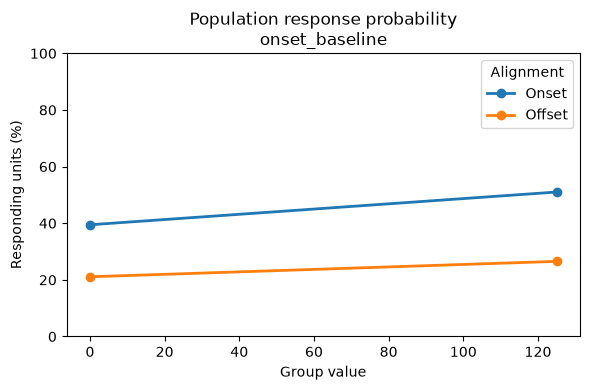

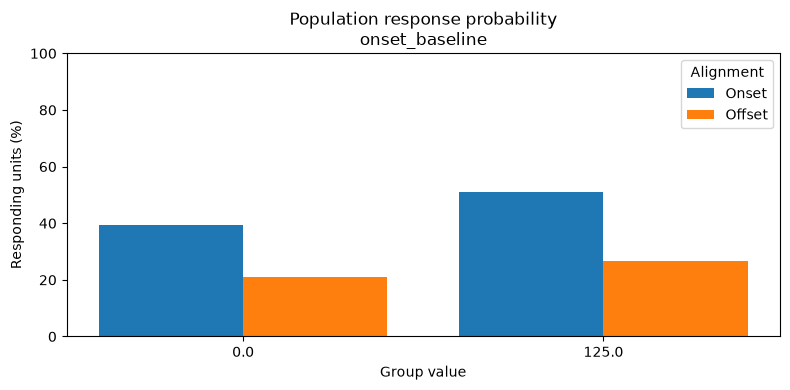

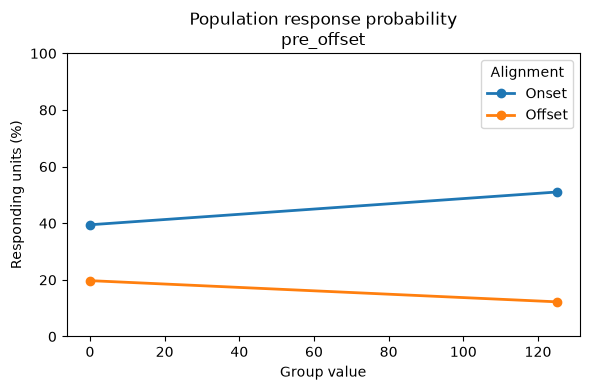

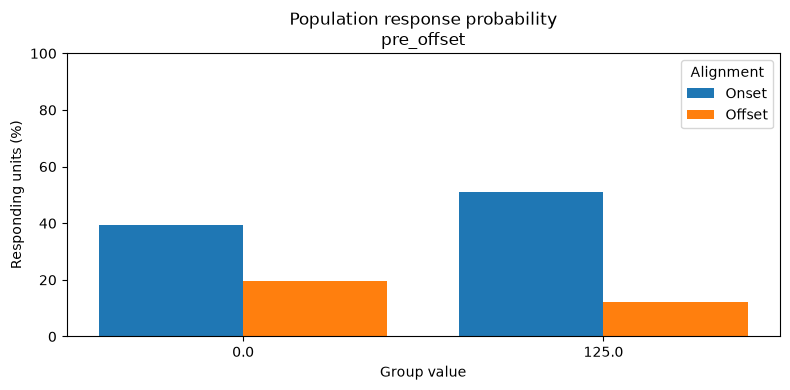

In [61]:
#38

# ==========================================
# Recording selection
# ==========================================

protocol = "del2"      # "dur", "pow", "lonstim", None (= all)

stim_mode = "B"       # "P", "L", "B", None (= all)

laser_mode = "N"      # "N", "LC", None (= all)

view = "Laser"        # "Laser", "Polychrome", None (= all)
# ==========================================
# Filter recordings
# ==========================================

filtered_summary = population_summary.copy()

if protocol is not None:
    filtered_summary = filtered_summary[
        filtered_summary["protocol"] == protocol
    ]

if stim_mode is not None:
    filtered_summary = filtered_summary[
        filtered_summary["stim_mode"] == stim_mode
    ]

if laser_mode is not None:
    filtered_summary = filtered_summary[
        filtered_summary["laser_mode"] == laser_mode
    ]

if view is not None:
    filtered_summary = filtered_summary[
        filtered_summary["view"] == view
    ]

# ------------------------------------------
# Check whether any data remain
# ------------------------------------------

if filtered_summary.empty:

    print(
        "\nNo data found with:\n"
        f"    protocol   = {protocol}\n"
        f"    stim_mode  = {stim_mode}\n"
        f"    laser_mode = {laser_mode}"
    )

else:

    print(
        f"\nSelected {len(filtered_summary)} rows"
    )

    print(
        f"Recordings: "
        f"{filtered_summary['rec_id'].nunique()}"
    )

    print(
        f"Units: "
        f"{filtered_summary['unit_id'].nunique()}"
    )

    # ==========================================
    # Population response summary
    # ==========================================

    def summarize_population_responses(
        population_summary,
    ):
        """
        Summarize the fraction of responding units
        for each stimulus condition.
        """

        summary = (
            population_summary
            .groupby(
                [
                    "baseline_mode",
                    "view",
                    "event",
                    "group_value",
                ],
                as_index=False,
            )
            .agg(

                n_units=(
                    "unit_id",
                    "count",
                ),

                n_responding=(
                    "responding",
                    "sum",
                ),

            )
        )

        summary["fraction_responding"] = (
            summary["n_responding"]
            / summary["n_units"]
        )

        summary["percent_responding"] = (
            100
            * summary["fraction_responding"]
        )

        return summary


    population_response_summary = (
        summarize_population_responses(
            filtered_summary
        )
    )

    display(population_response_summary)

    # ==========================================
    # Plot response probability
    # ==========================================

    baseline_modes = [
        "onset_baseline",
        "pre_offset",
    ]

    for baseline_mode in baseline_modes:

        baseline_df = (
            population_response_summary[
                population_response_summary[
                    "baseline_mode"
                ] == baseline_mode
            ]
        )

        if baseline_df.empty:
            continue

        # ------------------------------------------
        # Line plot
        # ------------------------------------------

        fig, ax = plt.subplots(figsize=(6, 4))

        for event in ["onset", "offset"]:

            df = (
                baseline_df[
                    baseline_df["event"] == event
                ]
                .sort_values("group_value")
            )

            ax.plot(
                df["group_value"],
                df["percent_responding"],
                marker="o",
                linewidth=2,
                label=event.capitalize(),
            )

        ax.set_xlabel("Group value")
        ax.set_ylabel("Responding units (%)")

        ax.set_title(
            f"Population response probability\n"
            f"{baseline_mode}"
        )

        ax.set_ylim(0, 100)

        ax.legend(
            title="Alignment"
        )

        plt.tight_layout()
        plt.show()

        # ------------------------------------------
        # Bar plot
        # ------------------------------------------

        fig, ax = plt.subplots(figsize=(8, 4))

        events = ["onset", "offset"]

        conditions = sorted(
            baseline_df["group_value"].unique()
        )

        x = np.arange(len(conditions))
        bar_width = 0.4

        for i, event in enumerate(events):

            df = (
                baseline_df[
                    baseline_df["event"] == event
                ]
                .set_index("group_value")
                .reindex(conditions)
            )

            ax.bar(
                x + (i - 0.5) * bar_width,
                df["percent_responding"],
                width=bar_width,
                label=event.capitalize(),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(conditions)

        ax.set_xlabel("Group value")
        ax.set_ylabel("Responding units (%)")

        ax.set_title(
            f"Population response probability\n"
            f"{baseline_mode}"
        )

        ax.set_ylim(0, 100)

        ax.legend(
            title="Alignment"
        )

        plt.tight_layout()
        plt.show()

#### What type of responses were observed?

,baseline_mode,view,event,group_value,n_units,n_excited,n_inhibited,n_mixed,n_none,n_responding
0,onset_baseline,Laser,offset,0.0,147,6,24,1,116,31
1,onset_baseline,Laser,offset,125.0,49,1,12,0,36,13
2,onset_baseline,Laser,onset,0.0,147,0,58,0,89,58
3,onset_baseline,Laser,onset,125.0,49,0,25,0,24,25
4,pre_offset,Laser,offset,0.0,147,23,5,1,118,29
5,pre_offset,Laser,offset,125.0,49,5,1,0,43,6
6,pre_offset,Laser,onset,0.0,147,0,58,0,89,58
7,pre_offset,Laser,onset,125.0,49,0,25,0,24,25


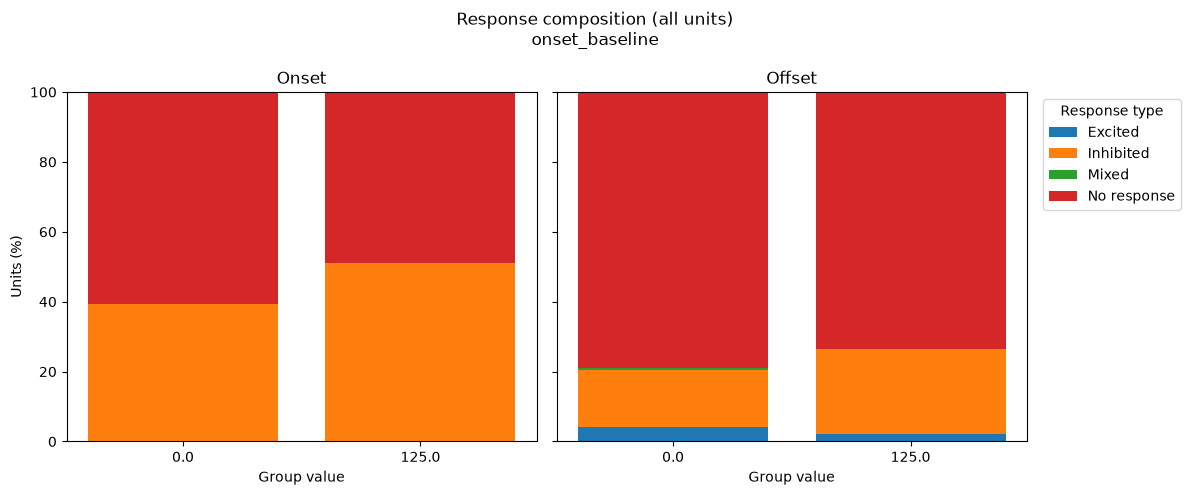

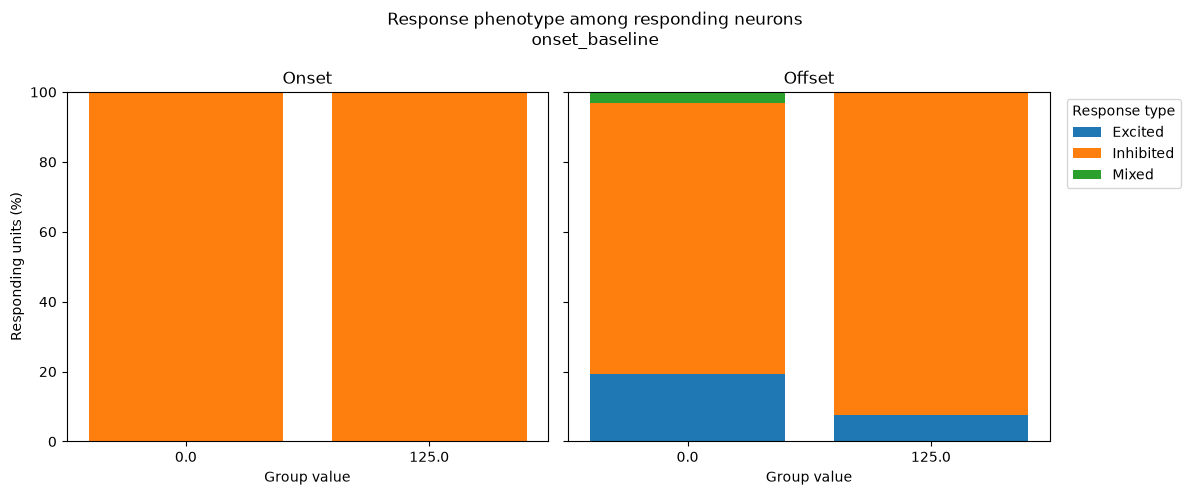

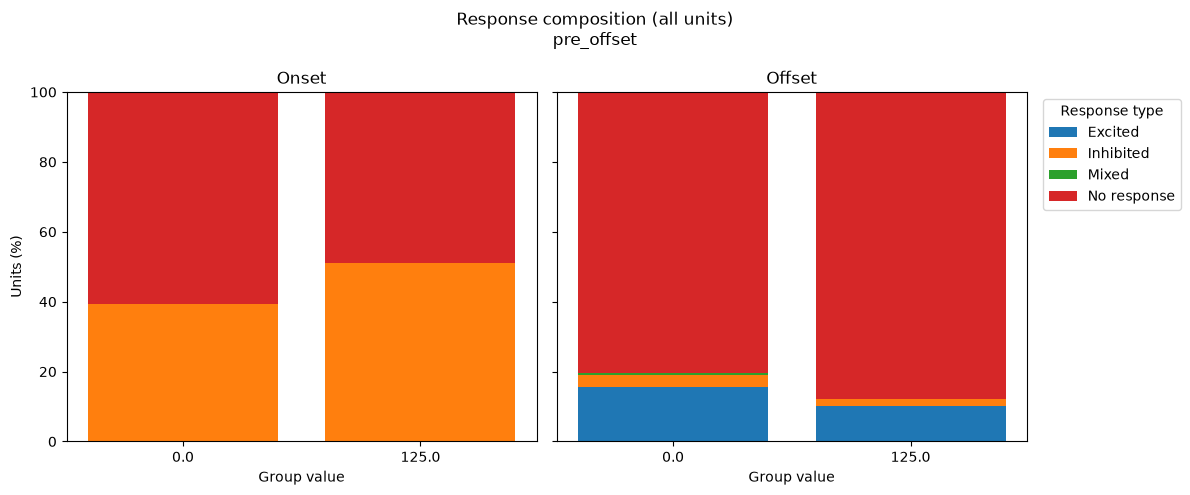

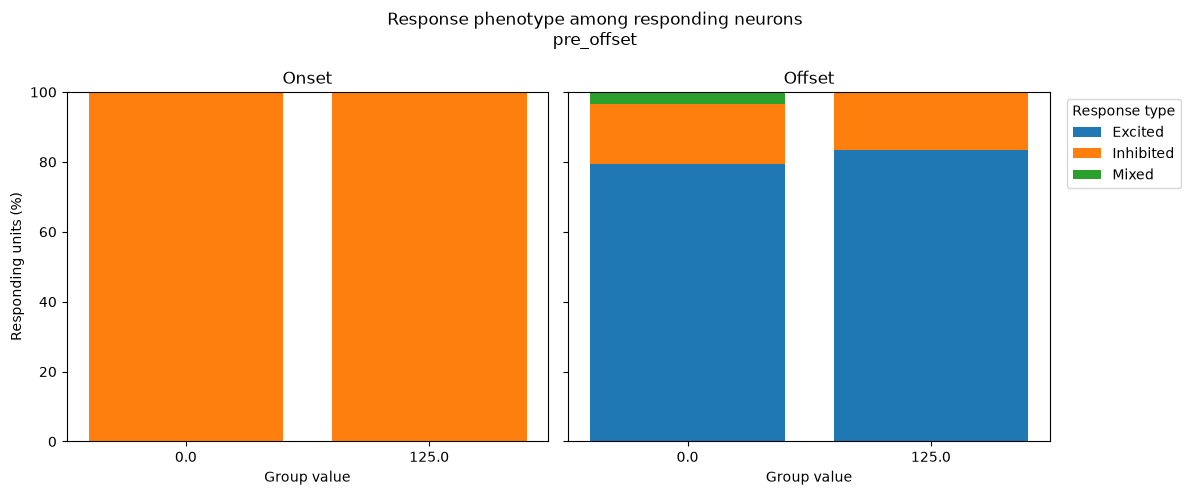

In [62]:
#39
# ==========================================
# Population response type summary
# ==========================================

"""
    Summarize the type of neuronal responses for each
    stimulus condition.

    Parameters
    ----------
    population_summary : pandas.DataFrame

    Returns
    -------
    pandas.DataFrame
    """

# ==========================================
# Population response type summary
# ==========================================

def summarize_response_types(population_summary):

    summary = (
        population_summary
        .groupby(
            [
                "baseline_mode",
                "view",
                "event",
                "group_value",
            ],
            as_index=False,
        )
        .agg(

            n_units=("unit_id", "count"),

            n_excited=(
                "response_type",
                lambda x: (x == "excited").sum(),
            ),

            n_inhibited=(
                "response_type",
                lambda x: (x == "inhibited").sum(),
            ),

            n_mixed=(
                "response_type",
                lambda x: (x == "mixed").sum(),
            ),

            n_none=(
                "response_type",
                lambda x: (x == "none").sum(),
            ),
        )
    )

    summary["n_responding"] = (

        summary["n_excited"]
        + summary["n_inhibited"]
        + summary["n_mixed"]

    )

    return summary


population_response_types = (
    summarize_response_types(
        filtered_summary
    )
)

display(population_response_types)

baseline_modes = [
    "onset_baseline",
    "pre_offset",
]

for baseline_mode in baseline_modes:

    baseline_df = (
        population_response_types[
            population_response_types["baseline_mode"]
            == baseline_mode
        ]
    )

    if baseline_df.empty:
        continue

    # ------------------------------------------
    # Figure 1
    # Response composition (all units)
    # ------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,5),
        sharey=True,
    )

    categories = [
        ("n_excited", "Excited"),
        ("n_inhibited", "Inhibited"),
        ("n_mixed", "Mixed"),
        ("n_none", "No response"),
    ]

    for ax, event in zip(axes, ["onset", "offset"]):

        df = (
            baseline_df
            .query("event == @event")
            .sort_values("group_value")
        )

        bottom = np.zeros(len(df))

        for column, label in categories:

            values = (
                100
                * df[column]
                / df["n_units"]
            )

            ax.bar(
                df["group_value"].astype(str),
                values,
                bottom=bottom,
                label=label,
            )

            bottom += values

        ax.set_title(event.capitalize())
        ax.set_xlabel("Group value")
        ax.set_ylim(0,100)

    axes[0].set_ylabel("Units (%)")

    axes[1].legend(
        title="Response type",
        bbox_to_anchor=(1.02,1),
    )

    plt.suptitle(
        f"Response composition (all units)\n"
        f"{baseline_mode}"
    )

    plt.tight_layout()
    plt.show()

    # ------------------------------------------
    # Figure 2
    # Response composition (responding units)
    # ------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,5),
        sharey=True,
    )

    categories = [
        ("n_excited", "Excited"),
        ("n_inhibited", "Inhibited"),
        ("n_mixed", "Mixed"),
    ]

    for ax, event in zip(axes, ["onset", "offset"]):

        df = (
            baseline_df
            .query("event == @event")
            .sort_values("group_value")
            .copy()
        )

        responding = df["n_responding"].replace(0, np.nan)

        bottom = np.zeros(len(df))

        for column, label in categories:

            values = (
                100
                * df[column]
                / responding
            ).fillna(0)

            ax.bar(
                df["group_value"].astype(str),
                values,
                bottom=bottom,
                label=label,
            )

            bottom += values

        ax.set_title(event.capitalize())
        ax.set_xlabel("Group value")
        ax.set_ylim(0,100)

    axes[0].set_ylabel("Responding units (%)")

    axes[1].legend(
        title="Response type",
        bbox_to_anchor=(1.02,1),
    )

    plt.suptitle(
        f"Response phenotype among responding neurons\n"
        f"{baseline_mode}"
    )

    plt.tight_layout()
    plt.show()



In [63]:
#40
population_summary["response_type"].value_counts(dropna=False)

response_type
none         6955
inhibited    2531
excited       109
mixed           9
Name: count, dtype: int64

In [64]:
#41
responding_units = (
    population_summary
    .loc[population_summary["responding"], "unit_id"]
    .unique()
)

print(responding_units)

<StringArray>
['uid_20260601_000', 'uid_20260601_001', 'uid_20260601_003',
 'uid_20260601_005', 'uid_20260601_006', 'uid_20260601_007',
 'uid_20260601_008', 'uid_20260601_009', 'uid_20260601_010',
 'uid_20260601_012', 'uid_20260601_014', 'uid_20260601_015',
 'uid_20260601_017', 'uid_20260601_018', 'uid_20260601_019',
 'uid_20260601_020', 'uid_20260601_021', 'uid_20260601_022',
 'uid_20260601_023', 'uid_20260601_024', 'uid_20260601_025',
 'uid_20260601_027', 'uid_20260601_028', 'uid_20260601_029',
 'uid_20260601_030', 'uid_20260601_031', 'uid_20260601_033',
 'uid_20260601_034', 'uid_20260601_035', 'uid_20260601_036',
 'uid_20260601_038', 'uid_20260601_041', 'uid_20260601_042',
 'uid_20260601_043', 'uid_20260601_044', 'uid_20260601_046',
 'uid_20260601_048', 'uid_20260601_016', 'uid_20260601_013',
 'uid_20260601_045', 'uid_20260601_011', 'uid_20260601_032',
 'uid_20260601_026', 'uid_20260601_039', 'uid_20260601_004',
 'uid_20260601_040', 'uid_20260601_002', 'uid_20260601_047',
 'uid_2026

#### Laser Duration PSTH

In [65]:
#42
# ==========================================
# Population PSTH configuration
# ==========================================

"""
Configure and select recordings for the population PSTH analysis.

This cell only performs data selection.

The following cells will

    #43  Reload aligned spike trains

    #44  Compute PSTHs

    #45  Plot PSTHs
"""

# ==========================================
# User settings
# ==========================================

protocol = "del2"
# "pow"
# "dur"
# "freq"
# "del"
# "del2"
# "longstim"
# None (= all)

stim_mode = "B"
# "P"
# "L"
# "B"
# None (= all)

laser_mode = "N"
# "N"
# "LC"
# None (= all)

view = "Polychrome"
# "Laser"
# "Polychrome"

include_units = "responding"
# "responding"
# "all"

baseline_mode = "pre_offset"
# "onset_baseline"
# "pre_offset"

event = "both"
# "onset"
# "offset"
# "both"

psth_alignment = "both"
# "onset"
# "offset"
# "both"

# PSTH parameters

analysis_window = (-500, 1500)

bin_width = 20      # ms

bin_step = 5        # ms

# ==========================================
# Filter population summary
# ==========================================

filtered_summary = population_summary.copy()

if protocol is not None:

    filtered_summary = filtered_summary[
        filtered_summary["protocol"] == protocol
    ]

if stim_mode is not None:

    filtered_summary = filtered_summary[
        filtered_summary["stim_mode"] == stim_mode
    ]

if laser_mode is not None:

    filtered_summary = filtered_summary[
        filtered_summary["laser_mode"] == laser_mode
    ]

if view is not None:

    filtered_summary = filtered_summary[
        filtered_summary["view"] == view
    ]

filtered_summary = filtered_summary[
    filtered_summary["baseline_mode"] == baseline_mode
]

# ------------------------------------------
# Alignment event
# ------------------------------------------

if event != "both":

    filtered_summary = filtered_summary[
        filtered_summary["event"] == event
    ]

# ------------------------------------------
# Responding filter
# ------------------------------------------

if include_units == "responding":

    filtered_summary = filtered_summary[
        filtered_summary["responding"]
    ]

elif include_units == "all":

    pass

else:

    raise ValueError(
        f"Unknown include_units: {include_units}"
    )

# ==========================================
# Check selection
# ==========================================

if filtered_summary.empty:

    if (
        protocol == "dur"
        and stim_mode == "L"
        and view == "Laser"
    ):

        print(
            "No laser duration data loaded."
        )

    else:

        print(
            "No recordings match the selected filters."
        )

else:

    print(
        "Population PSTH selection"
    )

    print(
        "-------------------------"
    )

    print(
        f"Session(s)   : "
        f"{filtered_summary['session_id'].nunique()}"
    )

    print(
        f"Recording(s) : "
        f"{filtered_summary['rec_id'].nunique()}"
    )

    print(
        f"Unit(s)      : "
        f"{filtered_summary['unit_id'].nunique()}"
    )

    print(
        f"Conditions   : "
        f"{len(filtered_summary['group_value'].unique())}"
    )

    print(
        f"View         : {view}"
    )

    print(
        f"Event        : {event}"
    )

    print(
        f"Units        : {include_units}"
    )

    display(

        filtered_summary[
            [
                "rec_id",
                "group_value",
                "event",
                "unit_id",
            ]
        ]
        .sort_values(
            [
                "rec_id",
                "group_value",
                "unit_id",
            ]
        )
        .head(20)

    )

Population PSTH selection
-------------------------
Session(s)   : 1
Recording(s) : 1
Unit(s)      : 46
Conditions   : 3
View         : Polychrome
Event        : both
Units        : responding


,rec_id,group_value,event,unit_id
7074,13_N_B_del2,0.0,onset,uid_20260601_000
7076,13_N_B_del2,0.0,onset,uid_20260601_000
7106,13_N_B_del2,0.0,onset,uid_20260601_001
7108,13_N_B_del2,0.0,onset,uid_20260601_001
7138,13_N_B_del2,0.0,onset,uid_20260601_002
7139,13_N_B_del2,0.0,offset,uid_20260601_002
7141,13_N_B_del2,0.0,offset,uid_20260601_002
7172,13_N_B_del2,0.0,onset,uid_20260601_003
7204,13_N_B_del2,0.0,onset,uid_20260601_004
7236,13_N_B_del2,0.0,onset,uid_20260601_005


#### Build population spike database (43)

In [66]:
#43
# ==========================================
# Build population spike database
# ==========================================

"""
Reload aligned spike trains for the selected units.

Each row corresponds to one trial from one stimulation
condition.

The resulting DataFrame is the input for all subsequent
population PSTH analyses.
"""

psth_rows = []

# ------------------------------------------
# Loop over sessions
# ------------------------------------------

for session_id in sorted(filtered_summary["session_id"].unique()):

    session_data = all_data_io[session_id]

    session_summary = filtered_summary[
        filtered_summary["session_id"] == session_id
    ]

    # --------------------------------------
    # Loop over recordings
    # --------------------------------------

    for rec_id in sorted(session_summary["rec_id"].unique()):

        print(f"Loading {rec_id}")

        recording_protocol = rec_id.split("_")[3]
        recording_stim_mode = rec_id.split("_")[2]

        (
            burst_df,
            analysis_views,
            group_label,
        ) = prepare_recording_analysis(

            data_io=session_data,

            rec_id=rec_id,

            protocol=recording_protocol,

            stim_mode=recording_stim_mode,

            pchr_columns=pchr_columns,

            laser_columns=laser_columns,

        )

        # --------------------------------------
        # Units belonging to this recording
        # --------------------------------------

        recording_summary = session_summary[
            session_summary["rec_id"] == rec_id
        ]

        unit_ids = sorted(
            recording_summary["unit_id"].unique()
        )

        # --------------------------------------
        # Reload aligned spikes
        # --------------------------------------

        for unit_id in unit_ids:

            all_spiketimes = extract_spikes(

                session_data,
                rec_id,
                unit_id,
                verbose=False,

            )

            unit_summary = recording_summary[
                recording_summary["unit_id"] == unit_id
            ]

            # ----------------------------------
            # Loop over selected conditions
            # ----------------------------------

            for _, row in unit_summary.iterrows():

                train_id = row["train_id"]

                event_name = row["event"]

                group_value = row["group_value"]

                metadata = row["metadata"]

                # ----------------------------------
                # Analysis view
                # ----------------------------------

                current_view = next(

                    v

                    for v in analysis_views

                    if v["name"] == view

                )

                # ----------------------------------
                # Stimulus windows
                # ----------------------------------

                alignment, stim_windows = (

                    current_view["stim_windows"](metadata)

                )

                # ----------------------------------
                # Unique stimulation pattern
                # ----------------------------------

                pattern_key = tuple(

                    (

                        int(round(start)),

                        int(round(stop)),

                        label,

                    )

                    for start, stop, label in stim_windows

                )

                view_spikes = all_spiketimes[view]

                if train_id not in view_spikes:

                    continue

                trial_spikes = view_spikes[train_id]

                # ----------------------------------
                # One row per trial
                # ----------------------------------

                for trial_index, spiketrain in enumerate(trial_spikes):

                    # ----------------------------------
                    # Store both alignments
                    # ----------------------------------

                    onset_spikes = spiketrain

                    offset_time = next(

                        stop

                        for _, stop, label in stim_windows

                        if label == view

                    )

                    offset_spikes = spiketrain - offset_time

                    psth_rows.append(

                        {

                            "session_id": session_id,

                            "rec_id": rec_id,

                            "unit_id": unit_id,

                            "view": view,

                            "event": event_name,

                            "group_value": group_value,

                            "train_id": train_id,

                            "trial": trial_index,

                            "metadata": metadata,

                            "stim_windows": stim_windows,

                            "pattern_key": pattern_key,

                            "onset_spikes": onset_spikes,

                            "offset_spikes": offset_spikes,

                        }

                    )

# ==========================================
# Build DataFrame
# ==========================================

psth_df = pd.DataFrame(psth_rows)

# ==========================================
# Summary
# ==========================================

print()

print("Population spike database")
print("-------------------------")

print(f"Trials      : {len(psth_df)}")

print(f"Units       : {psth_df['unit_id'].nunique()}")

print(f"Recordings  : {psth_df['rec_id'].nunique()}")

print(f"Conditions  : {sorted(psth_df['group_value'].unique())}")

display(
    psth_df.head()
)

Loading 13_N_B_del2

Population spike database
-------------------------
Trials      : 3540
Units       : 46
Recordings  : 1
Conditions  : [np.float64(0.0), np.float64(875.0), np.float64(1000.0)]


,session_id,rec_id,unit_id,view,event,group_value,train_id,trial,metadata,stim_windows,pattern_key,onset_spikes,offset_spikes
0,20260601_eye1_1st,13_N_B_del2,uid_20260601_000,Polychrome,onset,0.0,tid_054_13,0,pchr_onset 89661.5 pchr_offset...,"[(0.0, 125.0, Polychrome), (125.0, 1125.0, Las...","((0, 125, Polychrome), (125, 1125, Laser))","[-969.9499999999971, -925.4499999999971, -910....","[-1094.949999999997, -1050.449999999997, -1035..."
1,20260601_eye1_1st,13_N_B_del2,uid_20260601_000,Polychrome,onset,0.0,tid_054_13,1,pchr_onset 89661.5 pchr_offset...,"[(0.0, 125.0, Polychrome), (125.0, 1125.0, Las...","((0, 125, Polychrome), (125, 1125, Laser))","[-987.3000000000029, -891.4000000000087, -877....","[-1112.300000000003, -1016.4000000000087, -100..."
2,20260601_eye1_1st,13_N_B_del2,uid_20260601_000,Polychrome,onset,0.0,tid_054_13,2,pchr_onset 89661.5 pchr_offset...,"[(0.0, 125.0, Polychrome), (125.0, 1125.0, Las...","((0, 125, Polychrome), (125, 1125, Laser))","[-987.9031249999971, -896.1531249999971, -857....","[-1112.903124999997, -1021.1531249999971, -982..."
3,20260601_eye1_1st,13_N_B_del2,uid_20260601_000,Polychrome,onset,0.0,tid_054_13,3,pchr_onset 89661.5 pchr_offset...,"[(0.0, 125.0, Polychrome), (125.0, 1125.0, Las...","((0, 125, Polychrome), (125, 1125, Laser))","[-938.0968749999884, -920.796875, -878.5968749...","[-1063.0968749999884, -1045.796875, -1003.5968..."
4,20260601_eye1_1st,13_N_B_del2,uid_20260601_000,Polychrome,onset,0.0,tid_054_13,4,pchr_onset 89661.5 pchr_offset...,"[(0.0, 125.0, Polychrome), (125.0, 1125.0, Las...","((0, 125, Polychrome), (125, 1125, Laser))","[-989.3015624999971, -956.1515625000029, -926....","[-1114.301562499997, -1081.151562500003, -1051..."


#### PSTH Helper (44)

In [67]:
#44
# ==========================================
# Compute population PSTHs
# ==========================================

"""
Compute one population PSTH for each stimulus condition.

Workflow

    trials
        ↓
    mean within unit
        ↓
    mean across units
"""

# ------------------------------------------
# Sliding analysis windows
# ------------------------------------------

bin_starts = np.arange(

    analysis_window[0],

    analysis_window[1] - bin_width + bin_step,

    bin_step,

)

bin_centres = (

    bin_starts

    + bin_width / 2

)

# --------------------------------------
# Select spike alignment
# --------------------------------------

if psth_alignment == "onset":

    spike_columns = ["onset_spikes"]

elif psth_alignment == "offset":

    spike_columns = ["offset_spikes"]

elif psth_alignment == "both":

    spike_columns = [

        "onset_spikes",

        "offset_spikes",

    ]

else:

    raise ValueError(
        f"Unknown psth_alignment: {psth_alignment}"
    )

# ==========================================
# Compute PSTHs
# ==========================================

population_psth = {}

condition_keys = list(

    psth_df[
        ["group_value", "pattern_key"]
    ]

    .drop_duplicates()

    .itertuples(index=False, name=None)

)

for spike_column in spike_columns:

    alignment_name = spike_column.replace(
        "_spikes",
        "",
    )

    for group_value, pattern_key in condition_keys:

        print(

            f"{alignment_name:>6} | "

            f"{group_value} | "

            f"pattern {hash(pattern_key) % 1000}"

        )

        condition_df = (

            psth_df[

                (psth_df["group_value"] == group_value)

                &

                (psth_df["pattern_key"] == pattern_key)

            ]

        )

        # --------------------------------------
        # One PSTH per unit
        # --------------------------------------

        unit_rates = []

        for unit_id in sorted(

            condition_df["unit_id"].unique()

        ):

            unit_df = (

                condition_df[
                    condition_df["unit_id"] == unit_id
                ]

            )

            trial_rates = []

            for spiketrain in unit_df[spike_column]:

                counts = []

                for start in bin_starts:

                    n_spikes = np.sum(

                        (spiketrain >= start)

                        &

                        (spiketrain < start + bin_width)

                    )

                    counts.append(

                        n_spikes

                        * 1000

                        / bin_width

                    )

                trial_rates.append(counts)

            if len(trial_rates) == 0:

                continue

            trial_rates = np.asarray(trial_rates)

            # Mean PSTH for this unit

            unit_rates.append(

                trial_rates.mean(axis=0)

            )

        if len(unit_rates) == 0:

            continue

        unit_rates = np.asarray(unit_rates)

        # --------------------------------------
        # Store population statistics
        # --------------------------------------

        metadata = (

            condition_df.iloc[0]["metadata"]

        )

        stim_windows = (

            condition_df.iloc[0]["stim_windows"]

        )

        population_psth[
            (
                alignment_name,
                group_value,
                pattern_key,
            )
        ] = {

            "group_value": group_value,

            "pattern_key": pattern_key,

            "stim_windows": stim_windows,

            "alignment": alignment_name,

            "metadata": metadata,

            "time": bin_centres,

            "mean": unit_rates.mean(axis=0),

            "sem": (

                unit_rates.std(

                    axis=0,

                    ddof=1,

                )

                /

                np.sqrt(

                    unit_rates.shape[0]

                )

            ),

            "unit_rates": unit_rates,

            "n_units": unit_rates.shape[0],

            "n_trials": len(condition_df),

        }

# ==========================================
# Summary
# ==========================================

print()

print("Population PSTHs")
print("----------------")

for key in sorted(population_psth):

    psth = population_psth[key]

    print(

        f"{psth['alignment']:>6} | "

        f"{psth['group_value']:>8} | "

        f"{len(psth['stim_windows'])} windows"

    )

 onset | 0.0 | pattern 629
 onset | 0.0 | pattern 362
 onset | 1000.0 | pattern 836
 onset | 875.0 | pattern 538
offset | 0.0 | pattern 629
offset | 0.0 | pattern 362
offset | 1000.0 | pattern 836
offset | 875.0 | pattern 538

Population PSTHs
----------------
offset |      0.0 | 2 windows
offset |      0.0 | 2 windows
offset |    875.0 | 2 windows
offset |   1000.0 | 2 windows
 onset |      0.0 | 2 windows
 onset |      0.0 | 2 windows
 onset |    875.0 | 2 windows
 onset |   1000.0 | 2 windows


#### PSTH Plot (45)

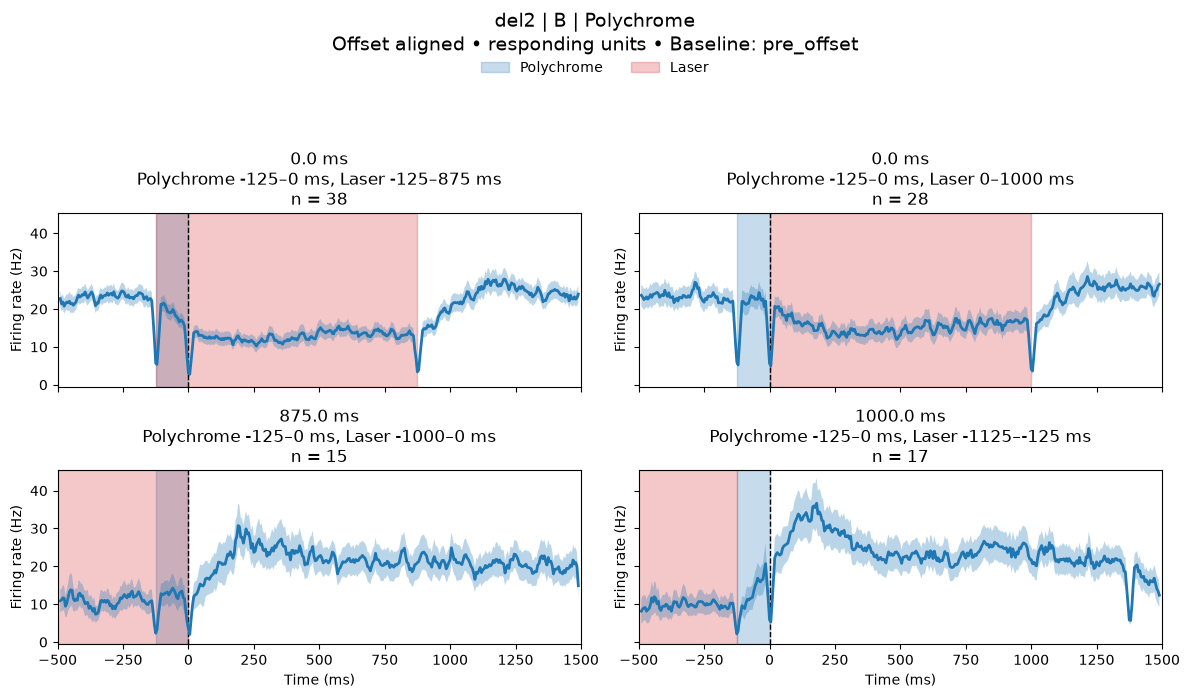

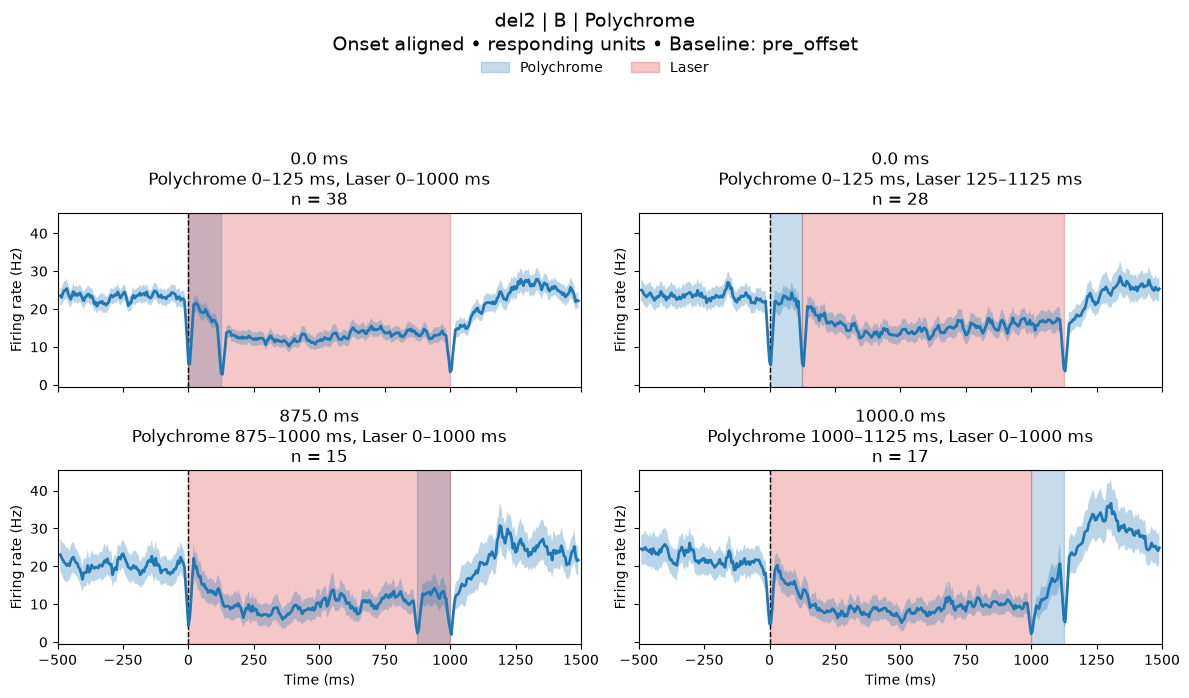

In [68]:
#45
# ==========================================
# Plot population PSTHs
# ==========================================

if len(population_psth) == 0:

    print("No PSTHs available.")

else:

    alignment_groups = {}

    for key, psth in population_psth.items():

        alignment_groups.setdefault(
            psth["alignment"],
            []
        ).append(key)

    for alignment_name in sorted(alignment_groups):

        conditions = sorted(alignment_groups[alignment_name])

        n_conditions = len(conditions)

        n_cols = 2

        n_rows = int(np.ceil(n_conditions / n_cols))

        fig, axes = plt.subplots(

            n_rows,

            n_cols,

            figsize=(12, 3.5 * n_rows),

            sharex=True,

            sharey=True,

        )

        axes = np.atleast_1d(axes).ravel()

        legend_added = {

            "Laser": False,

            "Polychrome": False,

        }

        # ======================================
        # Plot each PSTH
        # ======================================

        for ax, condition_key in zip(axes, conditions):

            psth = population_psth[condition_key]

            group_value = psth["group_value"]

            stim_windows = psth["stim_windows"]

            time = psth["time"]

            mean = psth["mean"]

            sem = psth["sem"]

            # ----------------------------------
            # Shift windows into display coordinates
            # ----------------------------------

            if alignment_name == "offset":

                reference = next(

                    stop

                    for _, stop, label in stim_windows

                    if label == view

                )

            else:

                reference = 0

            display_windows = []

            for start, stop, label in stim_windows:

                start -= reference
                stop -= reference

                display_windows.append(
                    (start, stop, label)
                )

                colour = (
                    "tab:red"
                    if label == "Laser"
                    else "tab:blue"
                )

                ax.axvspan(

                    start,

                    stop,

                    color=colour,

                    alpha=0.25,

                    zorder=0,

                    label=(
                        label
                        if not legend_added[label]
                        else None
                    ),

                )

                legend_added[label] = True

            # ----------------------------------
            # PSTH
            # ----------------------------------

            ax.axvline(

                0,

                color="black",

                linestyle="--",

                linewidth=1,

            )

            ax.plot(

                time,

                mean,

                linewidth=2,

            )

            ax.fill_between(

                time,

                mean-sem,

                mean+sem,

                alpha=0.30,

            )

            ax.set_xlim(analysis_window)

            ax.set_ylabel("Firing rate (Hz)")

            window_text = ", ".join(

                f"{label} {start:.0f}–{stop:.0f} ms"

                for start, stop, label in display_windows

            )

            ax.set_title(

                f"{group_value} ms\n"
                f"{window_text}\n"
                f"n = {psth['n_units']}"

            )

        # ----------------------------------
        # Hide empty panels
        # ----------------------------------

        for ax in axes[n_conditions:]:

            ax.set_visible(False)

        # ----------------------------------
        # Labels
        # ----------------------------------

        for ax in axes[-n_cols:]:

            if ax.get_visible():

                ax.set_xlabel("Time (ms)")

        handles, labels = axes[0].get_legend_handles_labels()

        if handles:

            fig.legend(

                handles,

                labels,

                loc="upper center",

                bbox_to_anchor=(0.5, 0.935),

                ncol=len(labels),

                frameon=False,

            )

        fig.suptitle(

            f"{protocol} | {stim_mode} | {view}\n"
            f"{alignment_name.capitalize()} aligned • "
            f"{include_units} units • "
            f"Baseline: {baseline_mode}",

            fontsize=14,

            y=0.99,

        )

        plt.tight_layout(

            rect=[0,0,1,0.90]

        )

        plt.show()

#### Compute unit PSTHs (46)

In [69]:
#46

# ==========================================
# Compute unit PSTHs
# ==========================================

"""
Compute one PSTH for every unit.

Workflow

    trials
        ↓
    mean within unit
        ↓
    store individual PSTHs

This database is used for heatmaps,
sorting and future population analyses.
"""

# ==========================================
# Compute unit PSTHs
# ==========================================

unit_psth = {}

condition_keys = list(

    psth_df[
        ["group_value", "pattern_key"]
    ]

    .drop_duplicates()

    .itertuples(index=False, name=None)

)

for spike_column in spike_columns:

    alignment_name = spike_column.replace(
        "_spikes",
        "",
    )

    for group_value, pattern_key in condition_keys:

        print(

            f"{alignment_name:>6} | "

            f"{group_value} | "

            f"pattern {hash(pattern_key)%1000}"

        )

        condition_df = psth_df[

            (psth_df["group_value"] == group_value)

            &

            (psth_df["pattern_key"] == pattern_key)

        ]

        metadata = condition_df.iloc[0]["metadata"]

        stim_windows = condition_df.iloc[0]["stim_windows"]

        units = []

        matrices = []

        # ----------------------------------
        # Compute one PSTH per unit
        # ----------------------------------

        for unit_id in sorted(

            condition_df["unit_id"].unique()

        ):

            unit_df = condition_df[
                condition_df["unit_id"] == unit_id
            ]

            trial_rates = []

            for spiketrain in unit_df[spike_column]:

                counts = []

                for start in bin_starts:

                    n_spikes = np.sum(

                        (spiketrain >= start)

                        &

                        (spiketrain < start + bin_width)

                    )

                    counts.append(

                        n_spikes
                        * 1000
                        / bin_width

                    )

                trial_rates.append(counts)

            if len(trial_rates) == 0:

                continue

            trial_rates = np.asarray(trial_rates)

            units.append(unit_id)

            matrices.append(

                trial_rates.mean(axis=0)

            )

        if len(matrices) == 0:

            continue

        matrices = np.asarray(matrices)

        unit_psth[
            (
                alignment_name,
                group_value,
                pattern_key,
            )
        ] = {

            "alignment": alignment_name,

            "group_value": group_value,

            "pattern_key": pattern_key,

            "metadata": metadata,

            "stim_windows": stim_windows,

            "time": bin_centres,

            "unit_ids": units,

            "matrix": matrices,

        }

# ==========================================
# Summary
# ==========================================

print()

print("Unit PSTHs")
print("----------")

for key in sorted(unit_psth):

    entry = unit_psth[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['group_value']:>8} | "

        f"{entry['matrix'].shape[0]:>3} units"

    )

 onset | 0.0 | pattern 629
 onset | 0.0 | pattern 362
 onset | 1000.0 | pattern 836
 onset | 875.0 | pattern 538
offset | 0.0 | pattern 629
offset | 0.0 | pattern 362
offset | 1000.0 | pattern 836
offset | 875.0 | pattern 538

Unit PSTHs
----------
offset |      0.0 |  38 units
offset |      0.0 |  28 units
offset |    875.0 |  15 units
offset |   1000.0 |  17 units
 onset |      0.0 |  38 units
 onset |      0.0 |  28 units
 onset |    875.0 |  15 units
 onset |   1000.0 |  17 units


#### Sort units and normalizing (47)

In [70]:
#47

# ==========================================
# Prepare heatmaps
# ==========================================

"""
Normalize, smooth and sort unit PSTHs.

Output
------
heatmap_data

One entry for each stimulation condition that is ready
for plotting.
"""

# ==========================================
# Settings
# ==========================================

heatmap_normalization = "zscore"
# "none"
# "zscore"
# "max"
# "baseline"

sort_units = "peak_latency"
# "none"
# "peak_latency"
# "peak_response"
# "mean_response"

sort_direction = "ascending"
# "ascending"
# "descending"

heatmap_smoothing = 0
# standard deviation (bins)
# 0 = no smoothing

baseline_window = (-200, 0)

# ==========================================
# Optional smoothing
# ==========================================

from scipy.ndimage import gaussian_filter1d

heatmap_data = {}

# ==========================================
# Process every condition
# ==========================================

for key, entry in unit_psth.items():

    matrix = entry["matrix"].copy()

    time = entry["time"]

    # --------------------------------------
    # Optional smoothing
    # --------------------------------------

    if heatmap_smoothing > 0:

        matrix = gaussian_filter1d(

            matrix,

            sigma=heatmap_smoothing,

            axis=1,

        )

    # --------------------------------------
    # Normalization
    # --------------------------------------

    if heatmap_normalization == "none":

        norm_matrix = matrix

    elif heatmap_normalization == "zscore":

        mean = matrix.mean(axis=1, keepdims=True)

        std = matrix.std(axis=1, keepdims=True)

        std[std == 0] = 1

        norm_matrix = (matrix - mean) / std

    elif heatmap_normalization == "max":

        maximum = matrix.max(axis=1, keepdims=True)

        maximum[maximum == 0] = 1

        norm_matrix = matrix / maximum

    elif heatmap_normalization == "baseline":

        baseline_mask = (

            (time >= baseline_window[0])

            &

            (time <= baseline_window[1])

        )

        baseline = matrix[:, baseline_mask].mean(

            axis=1,

            keepdims=True,

        )

        norm_matrix = matrix - baseline

    else:

        raise ValueError(

            f"Unknown normalization: "

            f"{heatmap_normalization}"

        )

    # --------------------------------------
    # Sorting metric
    # --------------------------------------

    if sort_units == "none":

        order = np.arange(norm_matrix.shape[0])

    elif sort_units == "peak_latency":

        order = np.argmax(

            norm_matrix,

            axis=1,

        )

        order = np.argsort(order)

    elif sort_units == "peak_response":

        order = np.argsort(

            norm_matrix.max(axis=1)

        )

    elif sort_units == "mean_response":

        response_mask = time >= 0

        order = np.argsort(

            norm_matrix[:, response_mask].mean(axis=1)

        )

    else:

        raise ValueError(

            f"Unknown sorting: "

            f"{sort_units}"

        )

    if sort_direction == "descending":

        order = order[::-1]

    # --------------------------------------
    # Store
    # --------------------------------------

    heatmap_data[key] = {

        **entry,

        "matrix":

            norm_matrix[order],

        "unit_ids":

            np.asarray(entry["unit_ids"])[order],

        "order":

            order,

    }

# ==========================================
# Summary
# ==========================================

print()

print("Heatmaps prepared")
print("-----------------")

print(

    f"Normalization : {heatmap_normalization}"

)

print(

    f"Sorting       : {sort_units}"

)

print(

    f"Smoothing     : {heatmap_smoothing}"

)

print()

for key in sorted(heatmap_data):

    entry = heatmap_data[key]

    print(

        f"{entry['alignment']:>6} | "

        f"{entry['group_value']:>8} | "

        f"{entry['matrix'].shape[0]:>3} units"

    )


Heatmaps prepared
-----------------
Normalization : zscore
Sorting       : peak_latency
Smoothing     : 0

offset |      0.0 |  38 units
offset |      0.0 |  28 units
offset |    875.0 |  15 units
offset |   1000.0 |  17 units
 onset |      0.0 |  38 units
 onset |      0.0 |  28 units
 onset |    875.0 |  15 units
 onset |   1000.0 |  17 units


#### Plot heatmaps (48)

C:\Users\au617715\AppData\Local\Temp\ipykernel_25620\3036523208.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


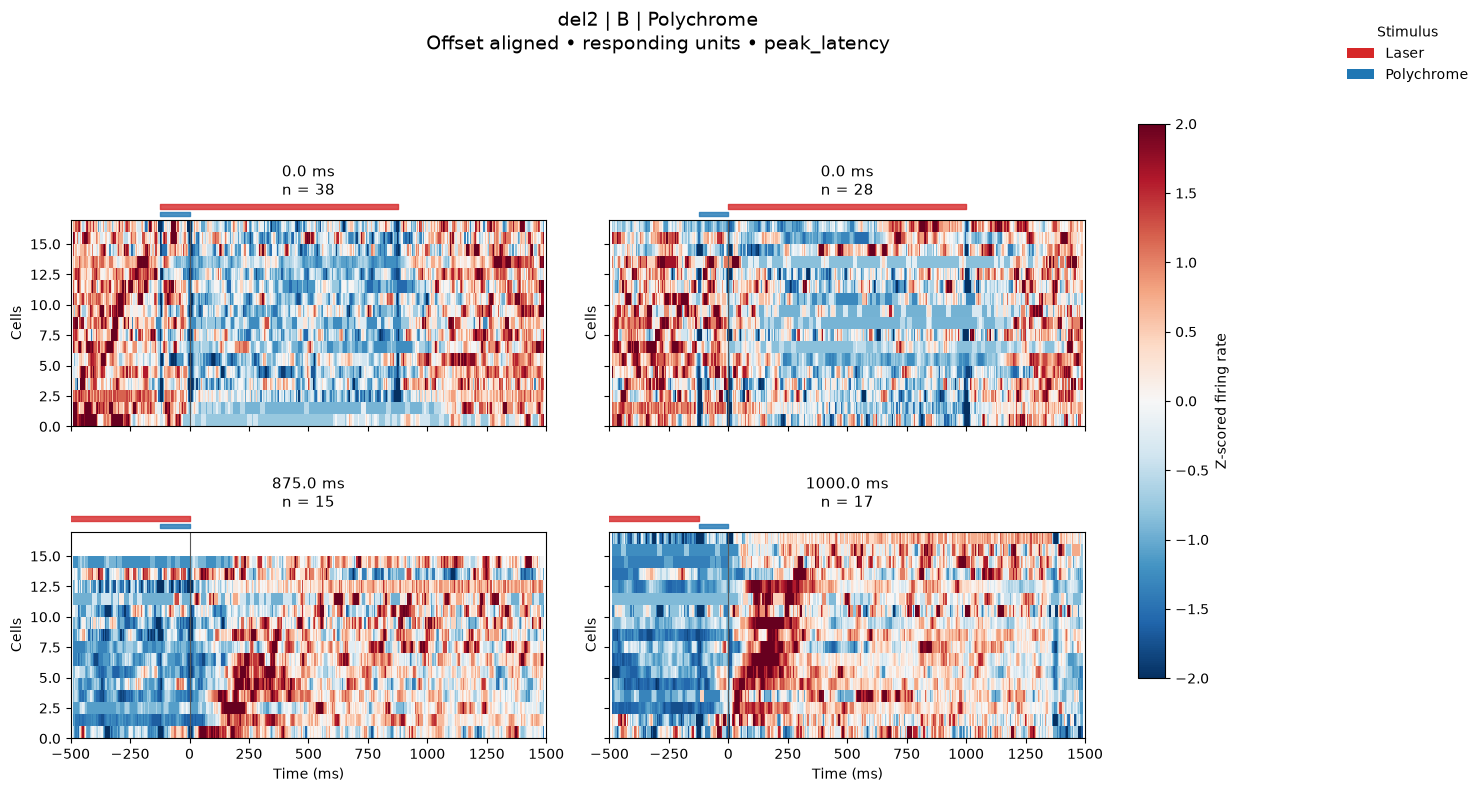

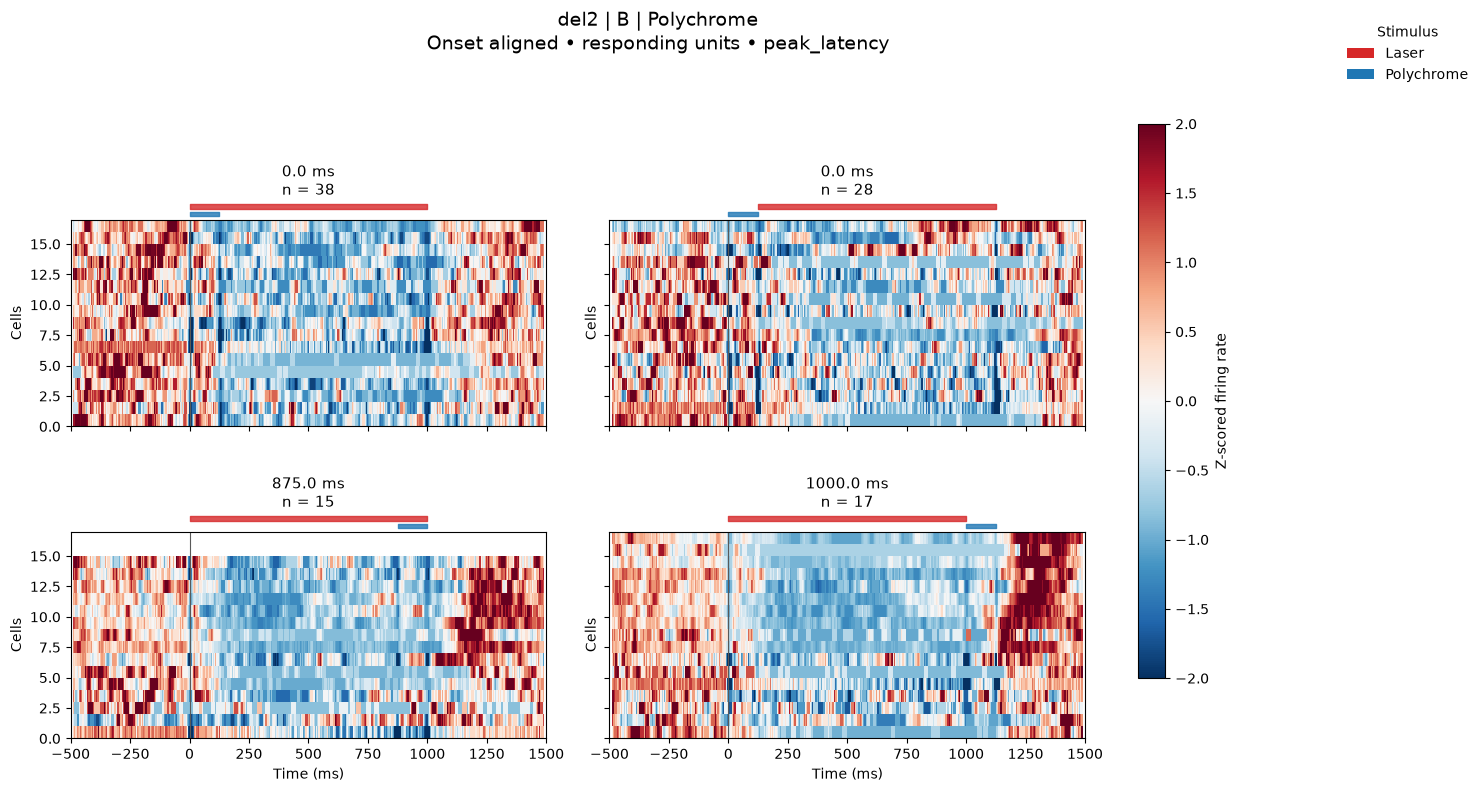

In [71]:
#48

# ==========================================
# Plot population heatmaps
# ==========================================

if len(heatmap_data) == 0:

    print("No heatmaps available.")

else:

    # ======================================
    # Group by alignment
    # ======================================

    alignment_groups = {}

    for key, entry in heatmap_data.items():

        alignment_groups.setdefault(
            entry["alignment"],
            []
        ).append(key)

    # ======================================
    # Plot each alignment separately
    # ======================================

    for alignment_name in sorted(alignment_groups):

        condition_keys = sorted(
            alignment_groups[alignment_name]
        )

        n_conditions = len(condition_keys)

        n_cols = 2

        n_rows = int(
            np.ceil(n_conditions / n_cols)
        )

        fig, axes = plt.subplots(

            n_rows,

            n_cols,

            figsize=(13, 4*n_rows),

            sharex=True,

            sharey=True,

        )

        axes = np.atleast_1d(axes).ravel()

        image = None

        legend_added = {

            "Laser": False,

            "Polychrome": False,

        }

        # ==================================
        # Plot each condition
        # ==================================

        for ax, key in zip(

            axes,

            condition_keys,

        ):

            entry = heatmap_data[key]

            matrix = entry["matrix"]

            time = entry["time"]

            stim_windows = entry["stim_windows"]

            group_value = entry["group_value"]

            # ------------------------------
            # Stimulus alignment
            # ------------------------------

            if alignment_name == "offset":

                reference = next(

                    stop

                    for _, stop, label in stim_windows

                    if label == view

                )

            else:

                reference = 0

            # ------------------------------
            # Heatmap
            # ------------------------------

            if heatmap_normalization == "zscore":

                vmin = -2

                vmax = 2

            elif heatmap_normalization == "max":

                vmin = 0

                vmax = 1

            else:

                vmin = None

                vmax = None

            image = ax.imshow(

                matrix,

                aspect="auto",

                origin="lower",

                extent=[

                    time[0],

                    time[-1],

                    0,

                    matrix.shape[0],

                ],

                cmap="RdBu_r",

                vmin=vmin,

                vmax=vmax,

                interpolation="nearest",

            )

            # ------------------------------
            # Stimulus schematic
            # ------------------------------

            stim_ax = ax.inset_axes(

                [0.0, 1.01, 1.0, 0.08]

            )

            stim_ax.set_xlim(analysis_window)

            stim_ax.set_ylim(0, 2)

            stim_ax.axis("off")

            for start, stop, label in stim_windows:

                start -= reference
                stop -= reference

                if label == "Laser":

                    y = 1.1
                    colour = "tab:red"

                else:

                    y = 0.2
                    colour = "tab:blue"

                stim_ax.fill_between(

                    [start, stop],

                    y,

                    y + 0.5,

                    color=colour,

                    alpha=0.8,

                )

                legend_added[label] = True

            # ------------------------------
            # Alignment marker
            # ------------------------------

            ax.axvline(

                0,

                color="0.35",

                linewidth=0.8,

            )

            # ------------------------------
            # Labels
            # ------------------------------

            ax.set_title(

                f"{group_value} ms\n"

                f"n = {matrix.shape[0]}",

                fontsize=11,

                pad=18,

            )

            ax.set_ylabel("Cells")

            ax.set_xlim(analysis_window)

        # ==================================
        # Hide unused panels
        # ==================================

        for ax in axes[n_conditions:]:

            ax.set_visible(False)

        # ==================================
        # X labels
        # ==================================

        for ax in axes[-n_cols:]:

            if ax.get_visible():

                ax.set_xlabel(

                    "Time (ms)"

                )

        from matplotlib.patches import Patch

        # ==================================
        # Stimulus legend
        # ==================================

        legend_handles = [

            Patch(
                facecolor="tab:red",
                edgecolor="none",
                label="Laser",
            ),

            Patch(
                facecolor="tab:blue",
                edgecolor="none",
                label="Polychrome",
            ),

        ]

        fig.legend(

            handles=legend_handles,

            loc="upper left",

            bbox_to_anchor=(1.02, 0.98),

            title="Stimulus",

            frameon=False,

        )

        # ==================================
        # Colourbar
        # ==================================

        visible_axes = [

            ax

            for ax in axes

            if ax.get_visible()

        ]

        cbar = fig.colorbar(

            image,

            ax=visible_axes,

            shrink=0.90,

            pad=0.02,

            fraction=0.04,

        )

        if heatmap_normalization == "zscore":

            cbar.set_label(

                "Z-scored firing rate"

            )

        elif heatmap_normalization == "max":

            cbar.set_label(

                "Normalized firing rate"

            )

        else:

            cbar.set_label(

                "Firing rate (Hz)"

            )

        # ==================================
        # Figure title
        # ==================================

        fig.suptitle(

            f"{protocol} | "

            f"{stim_mode} | "

            f"{view}\n"

            f"{alignment_name.capitalize()} aligned • "

            f"{include_units} units • "

            f"{sort_units}",

            fontsize=14,

            y=0.985,

        )

        plt.tight_layout(

            rect=[0, 0, 0.84, 0.92]

        )

        plt.show()

### Appendix: Debugging

In [72]:
from pathlib import Path
from pv_chip_aarhus.preprocessing.params import dataset_dir

sid = "20260601_eye1_1st"

trigger_dir = Path(dataset_dir) / sid / "trigger_files"
stim_dir = Path(dataset_dir) / sid / "stim_files"

print("Trigger files:")
for f in sorted(trigger_dir.glob("*_triggers.pkl")):
    print(f.name)

print("\nStim files:")
for f in sorted(stim_dir.glob("*.dat")):
    print(f.name)

Trigger files:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_2-pow_N_L_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_3-pow_LC_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_4-dur_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_06_4-dur_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_07_5-dur_N_L_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_08_6-dur_LC_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_09_7-freq_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_10_8-freq_N_L_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_11_9-freq_LC_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_12_10-del_N_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_13_11-del2_N_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_14_12-flick_N_L_triggers.pkl
2026060

In [73]:
from pv_chip_aarhus.preprocessing.lib.filepaths import FilePaths

sid = "20260601_eye1_1st"

filepaths = FilePaths(sid)

    20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_2-pow_N_L_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_3-pow_LC_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_4-dur_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_06_4-dur_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_07_5-dur_N_L_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_08_6-dur_LC_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_09_7-freq_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_10_8-freq_N_L_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_11_9-freq_LC_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_12_10-del_N_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_13_11-del2_N_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half

In [74]:
display(filepaths.recording_table)

,trigger_file,stim_file,lasermode,stimsource,laser_ch,varied_param
01,20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_...,01_pow_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,pow
02,20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_...,01_pow_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,pow
03,20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_...,02_pow_N_L_01-06-2026_ch8_eye1_1st_half.dat,N,L,ch8,pow
04,20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_...,03_pow_LC_B_01-06-2026_ch8_eye1_1st_half.dat,LC,B,ch8,pow
05,20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_...,04_dur_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,dur
06,20260601_PV_chip_rd1_770_eye1_1st_half_rec_06_...,04_dur_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,dur
07,20260601_PV_chip_rd1_770_eye1_1st_half_rec_07_...,05_dur_N_L_01-06-2026_ch8_eye1_1st_half.dat,N,L,ch8,dur
08,20260601_PV_chip_rd1_770_eye1_1st_half_rec_08_...,06_dur_LC_B_01-06-2026_ch8_eye1_1st_half.dat,LC,B,ch8,dur
09,20260601_PV_chip_rd1_770_eye1_1st_half_rec_09_...,07_freq_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,freq
10,20260601_PV_chip_rd1_770_eye1_1st_half_rec_10_...,08_freq_N_L_01-06-2026_ch8_eye1_1st_half.dat,N,L,ch8,freq


In [75]:
from pathlib import Path
from pv_chip_aarhus.preprocessing.params import dataset_dir

sid = "20260601_eye1_1st"

trigger_dir = (
    Path(dataset_dir)
    / sid
    / "trigger_files"
)

print("Trigger directory:")
print(trigger_dir)

for file in trigger_dir.iterdir():
    if "_triggers.pkl" in file.name:
        parts = file.name.split("_")

        print("\nFilename:")
        print(file.name)

        print(f"Number of parts: {len(parts)}")

        for i, part in enumerate(parts):
            print(i, part)

Trigger directory:
D:\ACJ\20260601\20260601 PV chip rd1 770 eye1 1st half\Analysis\raw_filtered\20260601_eye1_1st\trigger_files

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 01
10 1-pow
11 N
12 P
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 02
10 1-pow
11 N
12 P
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_2-pow_N_L_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 03
10 2-pow
11 N
12 L
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_3-pow_LC_B_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 04
10 3-pow
11 LC
12 B
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_4-dur_N_P